## Windkessel-Informed Neural Network for Cuffless BP Estimation 
==========================================================================

Physics constraint: 2-element Windkessel diastolic decay equation
 ##   DBP = SBP * exp(-decay_time / RC) ##
 
This constrains DBP to be consistent with the model's own SBP prediction
and the measured diastolic decay time (systolic peak -> dicrotic notch).
SBP remains purely data-driven (see explanation in accompanying chat message).
 
Sections:

    -  Peak / dicrotic notch detection  (feature extraction from raw PPG)

    -  RC estimation                    (fit once from training data)

    -  Windkessel physics loss          (the actual PINN constraint)

    - Model architecture               (simple 1D CNN)

    - Training loop                    (combines data loss + physics loss)

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import (
    find_peaks,
    savgol_filter
)
import h5py

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from torch.utils.data import Dataset, DataLoader

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Peak / Dicrotic Notch detection ##

Systolic peak = start of the "pressure is falling" phase, and dicrotic notch = the precise physiological start of diastole, where the heart is no longer pushing anything in.

For this eqn - P(t) = P_sys · exp(-t / RC)

We need t = decay time, which is simply the number of seconds it takes for arterial pressure to go from its systolic peak down to the start of the diastolic (passive) phase, measured as the time gap between the systolic peak and the dicrotic notch on the PPG waveform.

In [3]:
from PINN import prepare_UCI_dataset_w, get_dicrotic_notch, get_systolic_peak, get_delay_time, estimate_RC, grid_search_RC, train_resnet1d, create_data_loaders, run_windkessel_pinn, plot_training_loss,plot_pinn_training_metrics

In [4]:
wavelet = "db4"
level = 5
DATA_PATH = (f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}")

MAT_PATH = f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}/Part_1.mat"

In [5]:
FS = 125
WINDOW_SIZE = 1000


f = h5py.File(MAT_PATH, "r")

dataset = f["Part_1"]

# print("Number of recordings:", dataset.shape[0])
ref = dataset[1,0 ]

recording = f[ref][:]

print("Recording shape:", recording.shape)
ppg = recording[:, 0]
abp = recording[:, 1]

print("PPG length:", len(ppg))
print("ABP length:", len(abp))
ppg_std = np.std(ppg)


ppg = (ppg - np.mean(ppg)) / ppg_std # Normalize PPG signal
START = 0

ppg_window = ppg[
    START:START + WINDOW_SIZE
]

print("Window shape:", ppg_window.shape)


# ==========================================
# Detect ALL systolic peaks
# ==========================================

sys_peaks = get_systolic_peak(
    ppg_window,
    FS
)

print(
    "Number of systolic peaks:",
    len(sys_peaks)
)

print(
    "Systolic peak indices:",
    sys_peaks
)


# ==========================================
# Find notch after EACH systolic peak
# ==========================================
def calculate_derivatives(ppg, fs=125):

    # -----------------------------------
    # Smooth PPG
    # -----------------------------------

    smooth_ppg = savgol_filter(
        ppg,
        window_length=15,
        polyorder=3
    )

    # -----------------------------------
    # First derivative = VPG
    # -----------------------------------

    vpg = np.gradient(
        smooth_ppg
    ) * fs

    # -----------------------------------
    # Second derivative = APG
    # -----------------------------------

    apg = np.gradient(
        vpg
    ) * fs

    return smooth_ppg, vpg, apg
notches = []

for sys_idx in sys_peaks:
    smooth_ppg, vpg, apg = calculate_derivatives(
            ppg_window,
            FS
        )
    

    notch_idx = get_dicrotic_notch(
        ppg_window,
        sys_idx,
        vpg,
        apg,
        FS
    )

    notches.append(notch_idx)


# ==========================================
# Print results
# ==========================================

print("\nDetected landmarks:")

for i, (sys_idx, notch_idx) in enumerate(
    zip(sys_peaks, notches)
):

    print(
        f"Beat {i+1}: "
        f"Systolic = {sys_idx} "
        f"({sys_idx / FS:.3f} s), "
        f"Notch = {notch_idx}"
    )


delay_times = []

for sys_idx, notch_idx in zip(
    sys_peaks,
    notches
):

    if notch_idx is None:
        delay_times.append(np.nan)

    else:

        delay = (
            notch_idx - sys_idx
        ) / FS

        delay_times.append(delay)


delay_times = np.array(
    delay_times,
    dtype=np.float32
)


print("\nPeak → notch delays:")

for i, delay in enumerate(delay_times):

    if np.isnan(delay):

        print(
            f"Beat {i+1}: Detection failed"
        )

    else:

        print(
            f"Beat {i+1}: "
            f"{delay:.3f} seconds"
        )


Recording shape: (61000, 3)
PPG length: 61000
ABP length: 61000
Window shape: (1000,)
Number of systolic peaks: 15
Systolic peak indices: [ 55 120 184 248 312 377 441 506 569 633 697 761 824 887 951]

Detected landmarks:
Beat 1: Systolic = 55 (0.440 s), Notch = 74
Beat 2: Systolic = 120 (0.960 s), Notch = 138
Beat 3: Systolic = 184 (1.472 s), Notch = 203
Beat 4: Systolic = 248 (1.984 s), Notch = 267
Beat 5: Systolic = 312 (2.496 s), Notch = 333
Beat 6: Systolic = 377 (3.016 s), Notch = 397
Beat 7: Systolic = 441 (3.528 s), Notch = 461
Beat 8: Systolic = 506 (4.048 s), Notch = 525
Beat 9: Systolic = 569 (4.552 s), Notch = 588
Beat 10: Systolic = 633 (5.064 s), Notch = 652
Beat 11: Systolic = 697 (5.576 s), Notch = 716
Beat 12: Systolic = 761 (6.088 s), Notch = 783
Beat 13: Systolic = 824 (6.592 s), Notch = 844
Beat 14: Systolic = 887 (7.096 s), Notch = 907
Beat 15: Systolic = 951 (7.608 s), Notch = 970

Peak → notch delays:
Beat 1: 0.152 seconds
Beat 2: 0.144 seconds
Beat 3: 0.152 secon

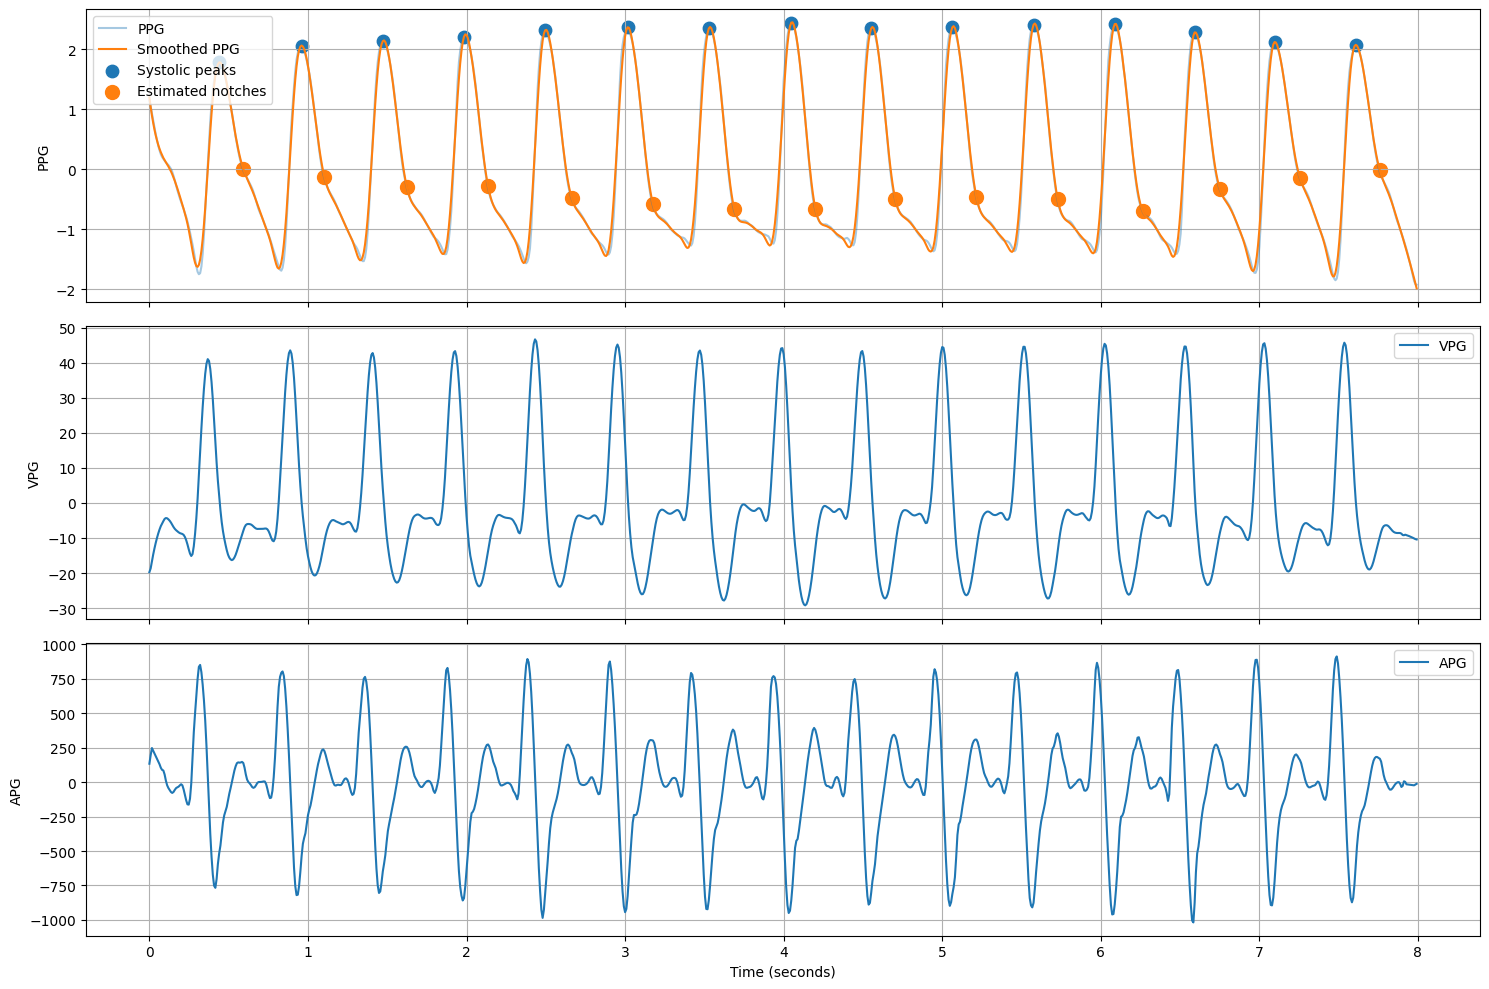

In [6]:
smooth_ppg = savgol_filter(
    ppg_window,
    window_length=21,
    polyorder=3
)
vpg = np.gradient(smooth_ppg) * FS
apg = np.gradient(vpg) * FS


time = np.arange(
    len(ppg_window)
) / FS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True
)


# ==================================================
# PPG
# ==================================================

axes[0].plot(
    time,
    ppg_window,
    alpha=0.4,
    label="PPG"
)

axes[0].plot(
    time,
    smooth_ppg,
    label="Smoothed PPG"
)


# All systolic peaks

axes[0].scatter(
    sys_peaks / FS,
    smooth_ppg[sys_peaks],
    s=80,
    label="Systolic peaks"
)


# All detected notches

valid_notches = [
    n for n in notches
    if n is not None
]

if len(valid_notches) > 0:

    valid_notches = np.array(
        valid_notches,
        dtype=int
    )

    axes[0].scatter(
        valid_notches / FS,
        smooth_ppg[valid_notches],
        s=100,
        label="Estimated notches"
    )


axes[0].set_ylabel("PPG")
axes[0].legend()
axes[0].grid()


# ==================================================
# VPG
# ==================================================

axes[1].plot(
    time,
    vpg,
    label="VPG"
)

axes[1].set_ylabel("VPG")
axes[1].legend()
axes[1].grid()


# ==================================================
# APG
# ==================================================

axes[2].plot(
    time,
    apg,
    label="APG"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("APG")
axes[2].legend()
axes[2].grid()


plt.tight_layout()
plt.show()

In [7]:
delay_time =  get_delay_time(ppg_window)
print(delay_time)

[0.152 0.144 0.152 0.152 0.168 0.16  0.16  0.152 0.152 0.152 0.152 0.176
 0.16  0.16  0.152]


In [8]:
X_train, y_train, delay_train, X_val, y_val, delay_val, X_test, y_test, delay_test = prepare_UCI_dataset_w(
    data_path=DATA_PATH, window_size=1000, step_size=1000)

Total recordings: 12000
Train recordings: 8400
Validation recordings: 1200
Test recordings: 2400

Processing TRAIN recordings...


Processing recordings: 100%|██████████| 8400/8400 [08:14<00:00, 16.97it/s]


Skipped recordings: 94

Processing VALIDATION recordings...


Processing recordings: 100%|██████████| 1200/1200 [01:12<00:00, 16.54it/s]


Skipped recordings: 14

Processing TEST recordings...


Processing recordings: 100%|██████████| 2400/2400 [02:26<00:00, 16.37it/s]


Skipped recordings: 16

DATASET SHAPES
X_train: torch.Size([229231, 1, 1000])
y_train: torch.Size([229231, 2])
delay_train: torch.Size([229231])
X_val: torch.Size([33007, 1, 1000])
y_val: torch.Size([33007, 2])
delay_val: torch.Size([33007])
X_test: torch.Size([67342, 1, 1000])
y_test: torch.Size([67342, 2])
delay_test: torch.Size([67342])


In [9]:
print("Shape:", delay_train.shape)
print("Dtype:", delay_train.dtype)
print("NaN count:", np.isnan(delay_train).sum())
delay_train_np = delay_train.detach().cpu().numpy().astype(np.float32)
print(
    "NaN percentage:",
    100 * np.isnan(delay_train_np).mean(),
    "%"
)

valid_delay = delay_train_np[
    np.isfinite(delay_train_np)
]

print("Valid values:", len(valid_delay))

if len(valid_delay) > 0:

    print("\nStatistics:")

    print(
        "Min    :",
        np.min(valid_delay)
    )

    print(
        "Max    :",
        np.max(valid_delay)
    )

    print(
        "Mean   :",
        np.mean(valid_delay)
    )

    print(
        "Median :",
        np.median(valid_delay)
    )

    print(
        "Std    :",
        np.std(valid_delay)
    )

if len(valid_delay) > 0:

    print("\nRange checks:")

    print(
        "Below 0.08 s:",
        np.sum(valid_delay < 0.08)
    )

    print(
        "Above 0.35 s:",
        np.sum(valid_delay > 0.35)
    )

    print(
        "Within 0.08–0.35 s:",
        np.sum(
            (valid_delay >= 0.08) &
            (valid_delay <= 0.35)
        )
    )


if len(valid_delay) > 0:

    print("\nPercentiles:")

    for p in [1, 5, 25, 50, 75, 95, 99]:

        print(
            f"{p:2d}% :",
            np.percentile(valid_delay, p)
        )

Shape: torch.Size([229231])
Dtype: torch.float32
NaN count: tensor(0)
NaN percentage: 0.0 %
Valid values: 229231

Statistics:
Min    : 0.104
Max    : 0.336
Mean   : 0.19038762
Median : 0.188
Std    : 0.027759466

Range checks:
Below 0.08 s: 0
Above 0.35 s: 0
Within 0.08–0.35 s: 229231

Percentiles:
 1% : 0.132
 5% : 0.148
25% : 0.17199999
50% : 0.188
75% : 0.208
95% : 0.232
99% : 0.264


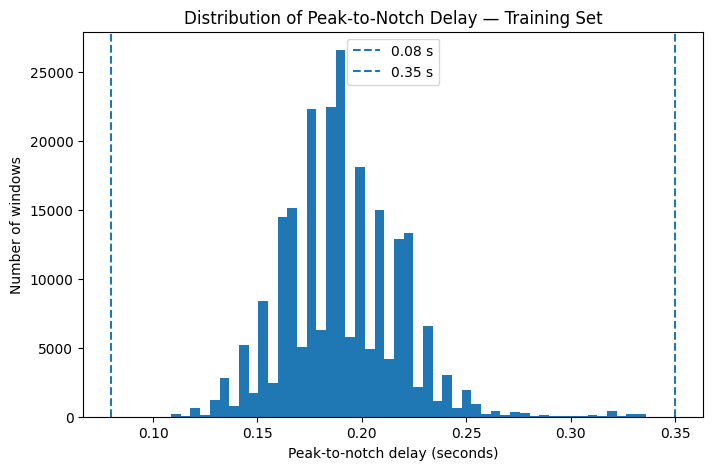

In [10]:
import matplotlib.pyplot as plt

valid_delay = delay_train[
    np.isfinite(delay_train)
]

plt.figure(figsize=(8, 5))

plt.hist(
    valid_delay,
    bins=50
)

plt.xlabel("Peak-to-notch delay (seconds)")
plt.ylabel("Number of windows")
plt.title("Distribution of Peak-to-Notch Delay — Training Set")

plt.axvline(
    0.08,
    linestyle="--",
    label="0.08 s"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="0.35 s"
)

plt.legend()

plt.show()

In [11]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("delay_train:", delay_train.shape)

print(
    "Number of windows:",
    len(X_train)
)

print(
    "Number of BP labels:",
    len(y_train)
)

print(
    "Number of delays:",
    len(delay_train)
)

X_train: torch.Size([229231, 1, 1000])
y_train: torch.Size([229231, 2])
delay_train: torch.Size([229231])
Number of windows: 229231
Number of BP labels: 229231
Number of delays: 229231


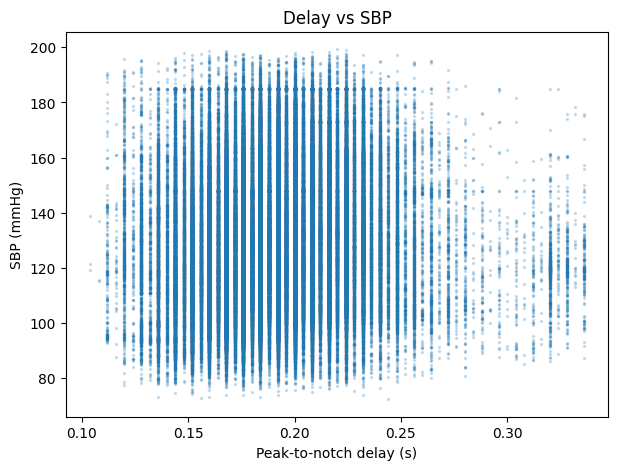

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 0],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("SBP (mmHg)")
plt.title("Delay vs SBP")

plt.show()

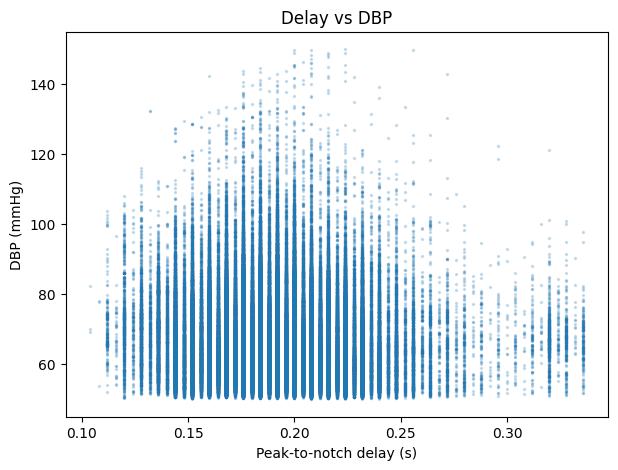

In [13]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 1],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("DBP (mmHg)")
plt.title("Delay vs DBP")

plt.show()

## RC Estimation ##

In [14]:
RC, RC_values = estimate_RC(
    sbp=y_train[:, 0].numpy(),
    dbp=y_train[:, 1].numpy(),
    delay=delay_train
)

Total windows: 229231
Valid windows: 229231
Valid percentage: 100.0 %

Windkessel RC Estimation
Median RC : 0.2826 s
Mean RC   : 0.3035 s
Std RC    : 0.1023 s
Min RC    : 0.1126 s
Max RC    : 1.6756 s


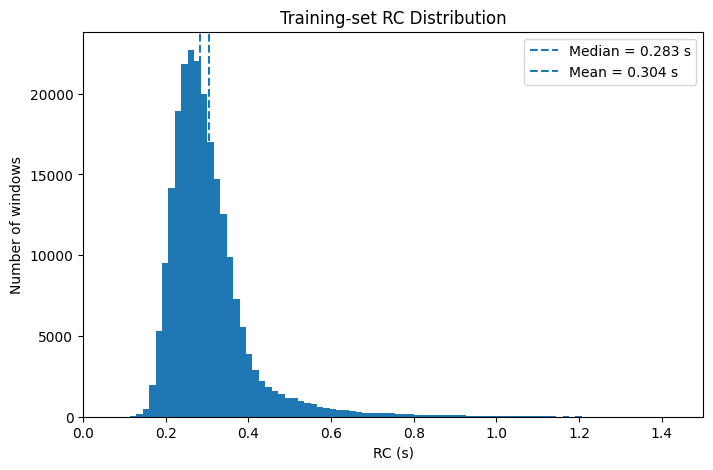

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    RC_values,
    bins=100
)

plt.axvline(
    np.median(RC_values),
    linestyle="--",
    label=f"Median = {np.median(RC_values):.3f} s"
)
plt.axvline(
    np.mean(RC_values),
    linestyle="--",
    label=f"Mean = {np.mean(RC_values):.3f} s"
)

plt.xlabel("RC (s)")
plt.xlim(0,1.5)
plt.ylabel("Number of windows")
plt.title("Training-set RC Distribution")
plt.legend()

plt.show()

It's a highly skewed distribution, so using mean won't be a good idea

In [16]:
for p in [1, 5, 25, 50, 75, 90, 95, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(RC_values, p):.4f} s"
    )

  1.0% : 0.1729 s
  5.0% : 0.1973 s
 25.0% : 0.2425 s
 50.0% : 0.2826 s
 75.0% : 0.3349 s
 90.0% : 0.4019 s
 95.0% : 0.4844 s
 99.0% : 0.7281 s
 99.5% : 0.8369 s
 99.9% : 1.0613 s


In [17]:
RC = 0.2994

sbp = y_train[:, 0].cpu().numpy()
dbp = y_train[:, 1].cpu().numpy()
delay = delay_train.cpu().numpy()

dbp_physics = (
    sbp *
    np.exp(-delay / RC)
)

physics_mae = np.mean(
    np.abs(dbp_physics - dbp)
)

physics_rmse = np.sqrt(
    np.mean(
        (dbp_physics - dbp) ** 2
    )
)

print("Physics-only DBP MAE :", physics_mae)
print("Physics-only DBP RMSE:", physics_rmse)

Physics-only DBP MAE : 9.138204
Physics-only DBP RMSE: 11.874546


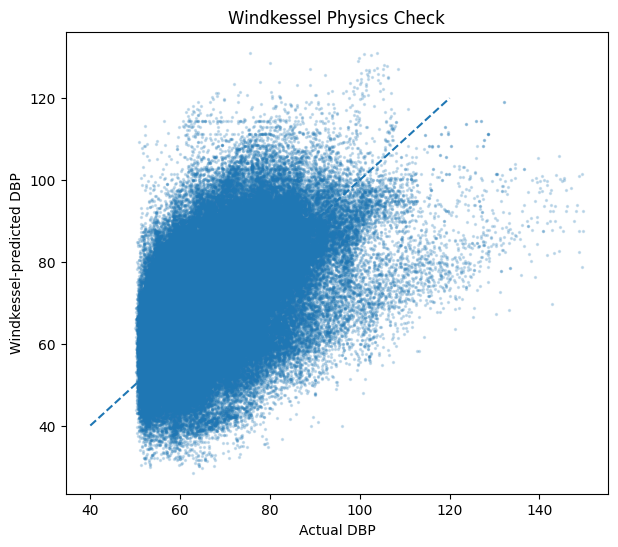

In [18]:
plt.figure(figsize=(7, 6))

plt.scatter(
    dbp,
    dbp_physics,
    s=2,
    alpha=0.2
)

plt.plot(
    [40, 120],
    [40, 120],
    linestyle="--"
)

plt.xlabel("Actual DBP")
plt.ylabel("Windkessel-predicted DBP")
plt.title("Windkessel Physics Check")

plt.show()

In [19]:
rc_values, mae_values, rmse_values, best_RC_MAE, best_RC_RMSE = grid_search_RC(
    sbp=y_train[:, 0].cpu().numpy(),
    dbp=y_train[:, 1].cpu().numpy(),
    delay=delay_train.cpu().numpy(),
    rc_min=0.10,
    rc_max=1.00,
    rc_step=0.005
)
RC = best_RC_MAE

Valid samples: 229231

RC GRID SEARCH RESULTS
Best RC by MAE  : 0.2800 s
Best MAE        : 8.7615 mmHg

Best RC by RMSE : 0.2800 s
Best RMSE       : 11.4606 mmHg


## Establishing Baseline using 1D ResNet ##

In [20]:
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [21]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([229231, 1, 1000])
y_train: torch.Size([229231, 2])
X_val: torch.Size([33007, 1, 1000])
y_val: torch.Size([33007, 2])
X_test: torch.Size([67342, 1, 1000])
y_test: torch.Size([67342, 2])


In [22]:
train_loader, val_loader, test_loader = create_data_loaders(
    X_train, y_train,
    X_val, y_val,  
    X_test, y_test)


Epoch [01/50] LR: 1.00e-04 | Train MSE: 7680.7524 | Train SBP MSE: 12670.9665 | Train DBP MSE: 2690.5383 | Train SBP RMSE: 112.5654 | Train DBP RMSE: 51.8704 | Val MSE: 4718.6607 | Val SBP MSE: 8437.1879 | Val DBP MSE: 1000.1335 | Val SBP RMSE: 91.8542 | Val DBP RMSE: 31.6249
Epoch [02/50] LR: 1.00e-04 | Train MSE: 2876.5611 | Train SBP MSE: 5302.8798 | Train DBP MSE: 450.2425 | Train SBP RMSE: 72.8209 | Train DBP RMSE: 21.2189 | Val MSE: 1611.4971 | Val SBP MSE: 3070.8951 | Val DBP MSE: 152.0991 | Val SBP RMSE: 55.4157 | Val DBP RMSE: 12.3328
Epoch [03/50] LR: 1.00e-04 | Train MSE: 705.8232 | Train SBP MSE: 1289.7579 | Train DBP MSE: 121.8886 | Train SBP RMSE: 35.9132 | Train DBP RMSE: 11.0403 | Val MSE: 276.6471 | Val SBP MSE: 424.4667 | Val DBP MSE: 128.8275 | Val SBP RMSE: 20.6026 | Val DBP RMSE: 11.3502
Epoch [04/50] LR: 1.00e-04 | Train MSE: 268.4499 | Train SBP MSE: 423.7413 | Train DBP MSE: 113.1586 | Train SBP RMSE: 20.5850 | Train DBP RMSE: 10.6376 | Val MSE: 261.8648 | Val S

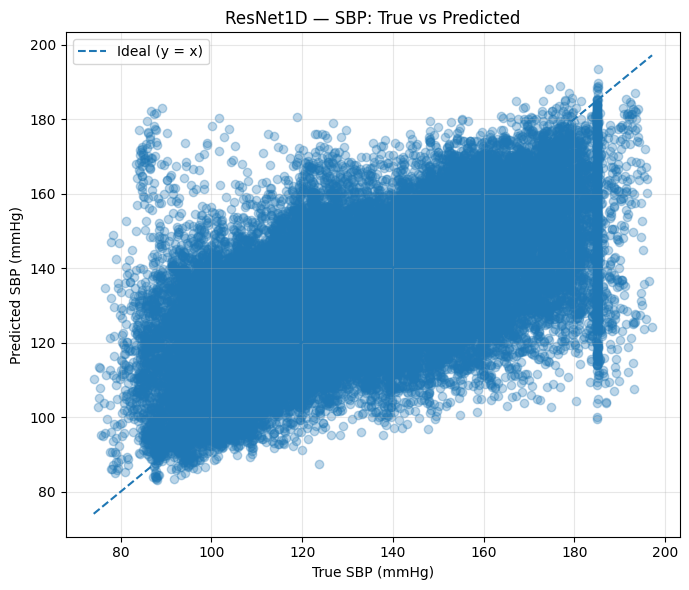

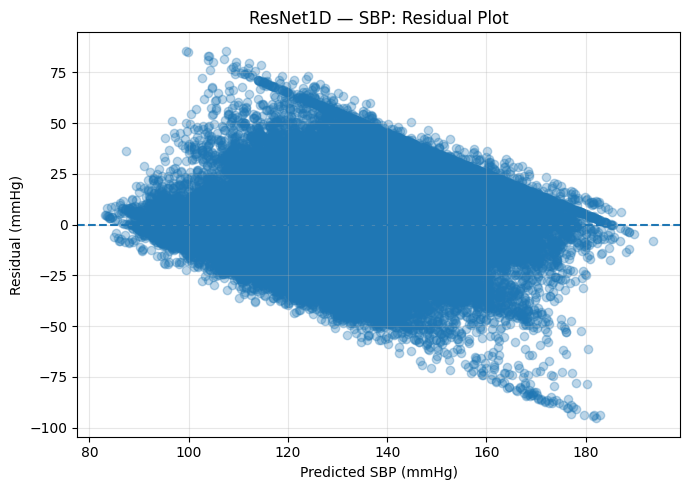

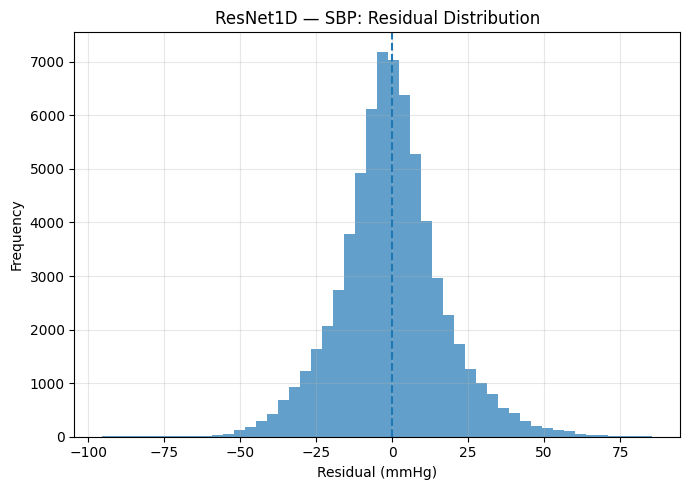

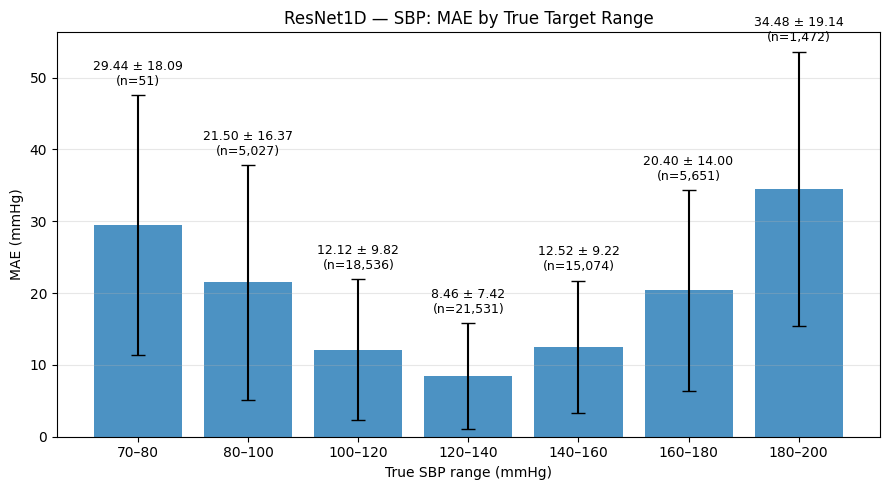



DBP TEST RESULTS
RMSE: 9.1271
MSE : 83.3042
R²  : 0.3282
MAE : 6.5228


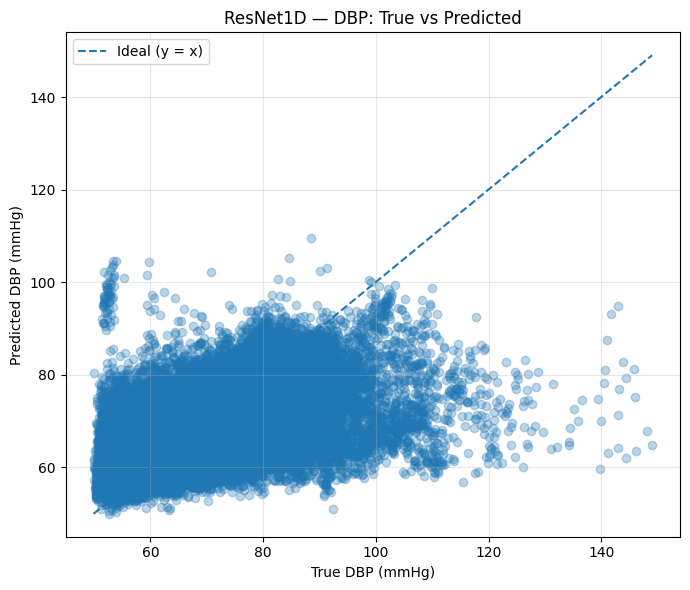

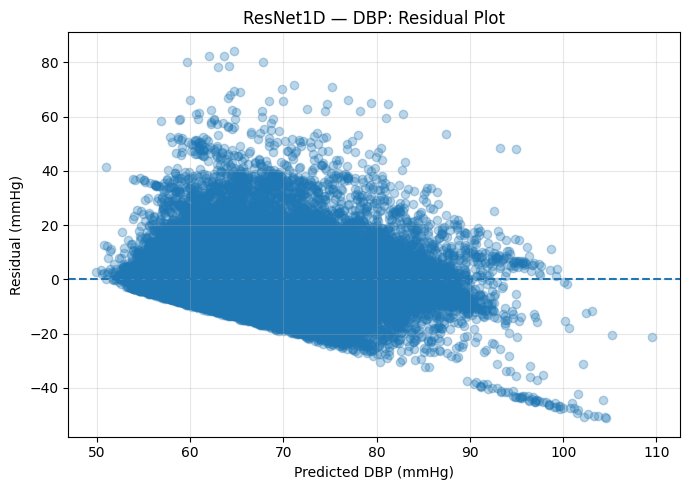

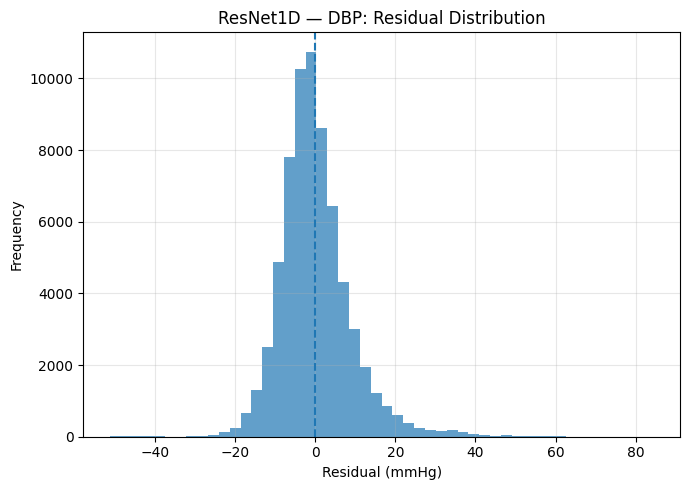

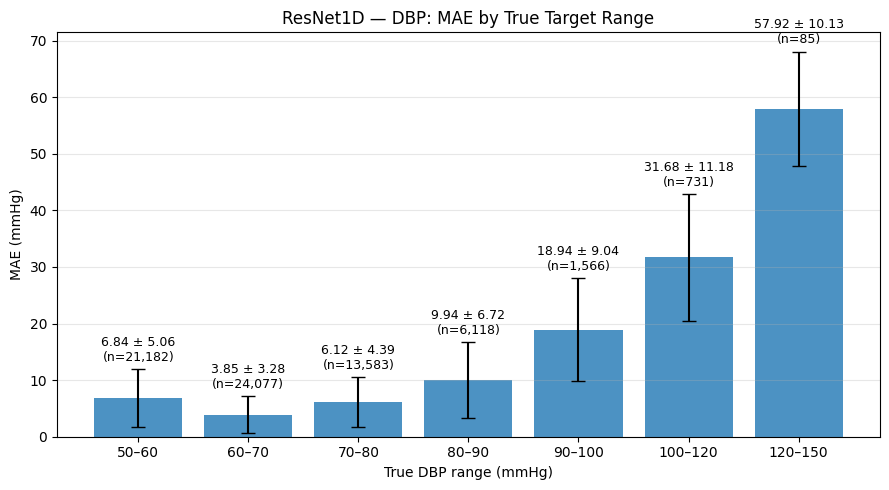

In [23]:
model, history, y_true, y_pred = train_resnet1d(
    train_loader,
    val_loader,
    test_loader,
    device,
    epochs=50
)

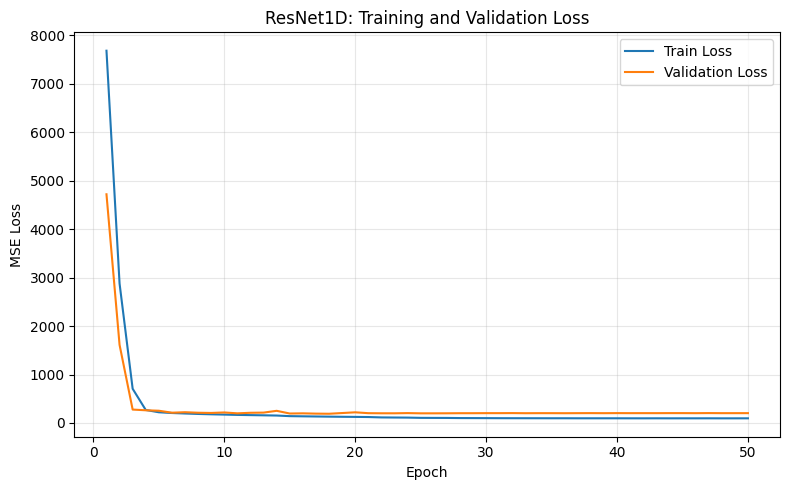

In [24]:
plot_training_loss(
    history,
    model_name="ResNet1D"
)

## Physics Informed Windkessel ##

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15840.8739 | Train SBP MSE: 13002.1244 | Train DBP MSE: 2838.7442 | Train Phys: 53.9368 | Train RMSE: SBP=114.027, DBP=53.280 | Val Total: 10533.6451 | Val SBP MSE: 9264.4026 | Val DBP MSE: 1269.2232 | Val Phys: 193.9177 | Val RMSE: SBP=96.252, DBP=35.626 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 5820.2864 | Train SBP MSE: 5370.8665 | Train DBP MSE: 449.3779 | Train Phys: 420.8599 | Train RMSE: SBP=73.286, DBP=21.199 | Val Total: 2979.0925 | Val SBP MSE: 2835.9234 | Val DBP MSE: 143.1327 | Val Phys: 363.9795 | Val RMSE: SBP=53.253, DBP=11.964 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1005.9557 | Train SBP MSE: 892.2775 | Train DBP MSE: 113.6605 | Train Phys: 176.3877 | Train RMSE: SBP=29.871, DBP=10.661 | Val Total: 530.4208 | Val SBP MSE: 433.6398 | Val DBP MSE: 96.7766 | Val Phys: 43.9384 | Val RMSE: SBP=20.824, DBP=9.838 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 477.2673 | Train SBP MSE: 369.8878 | Train DBP MSE: 107.

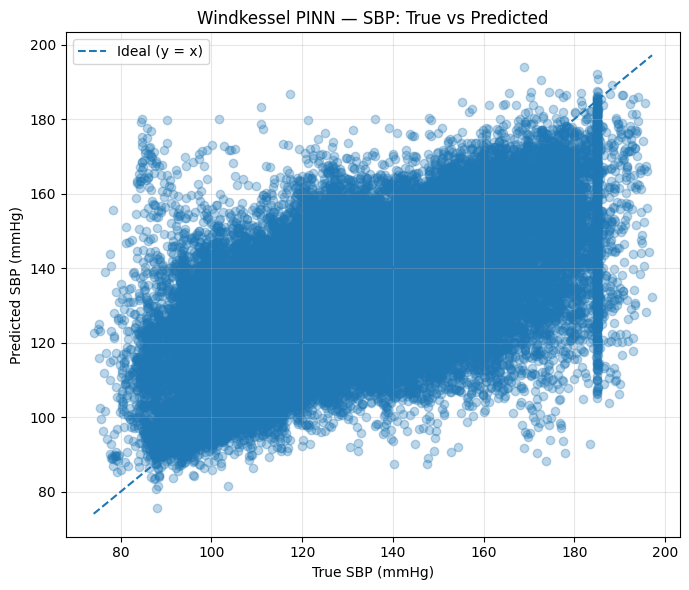

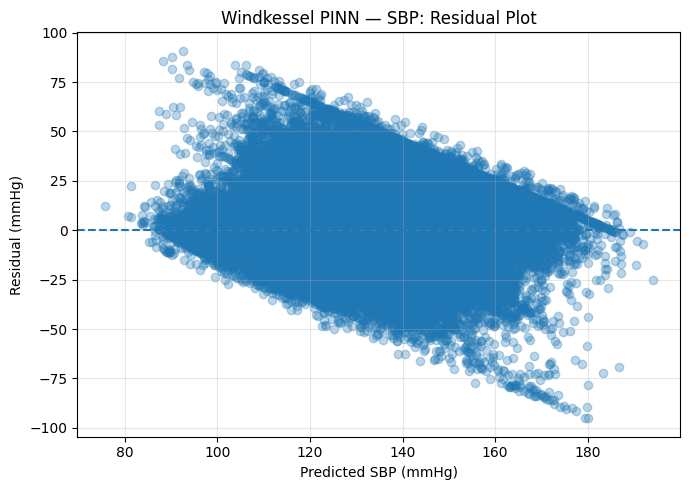

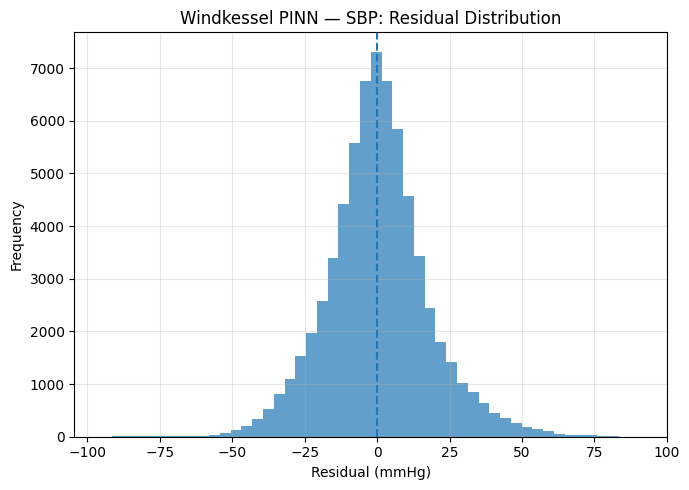

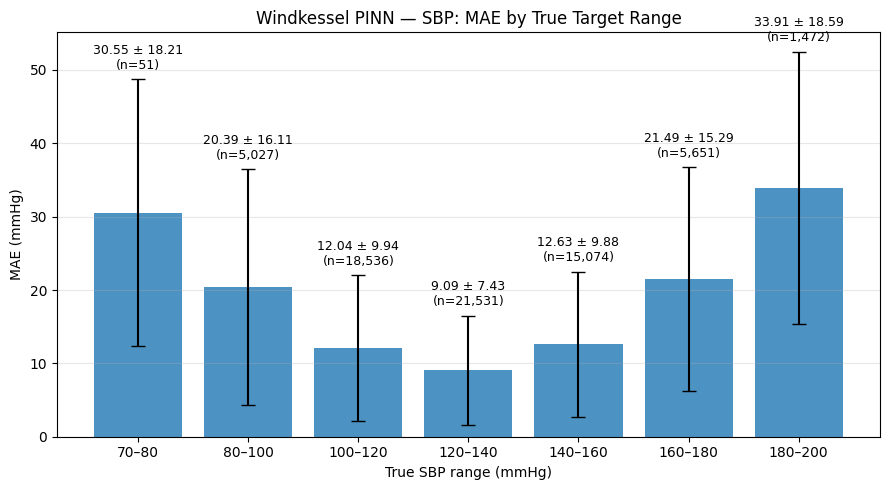


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.1298
MSE : 83.3530
R²  : 0.3278
MAE : 6.4868


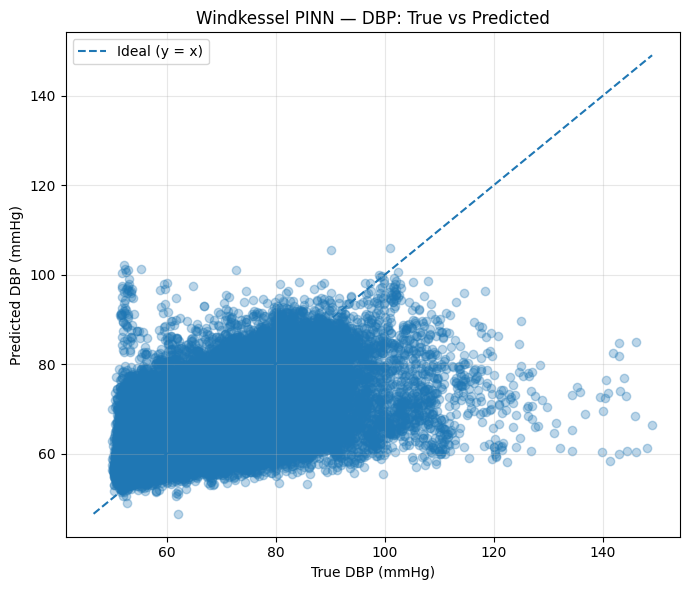

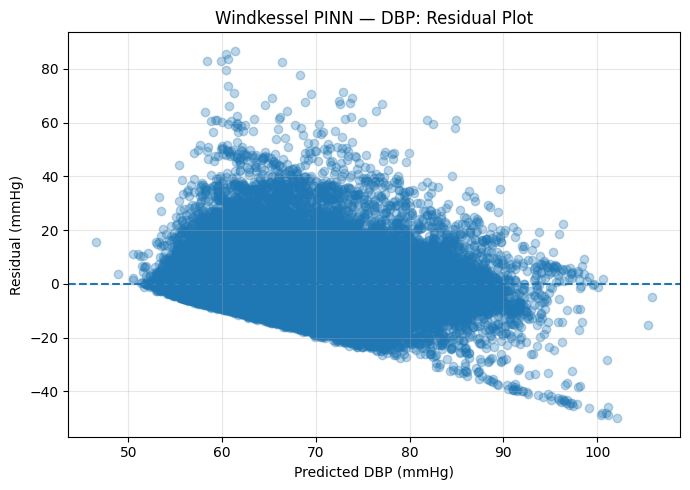

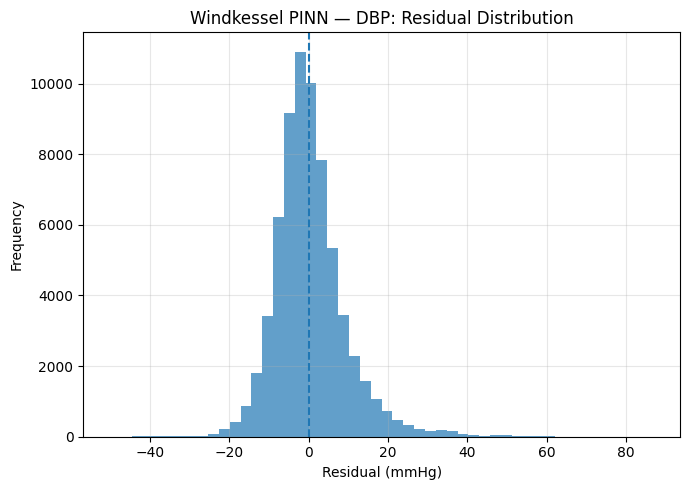

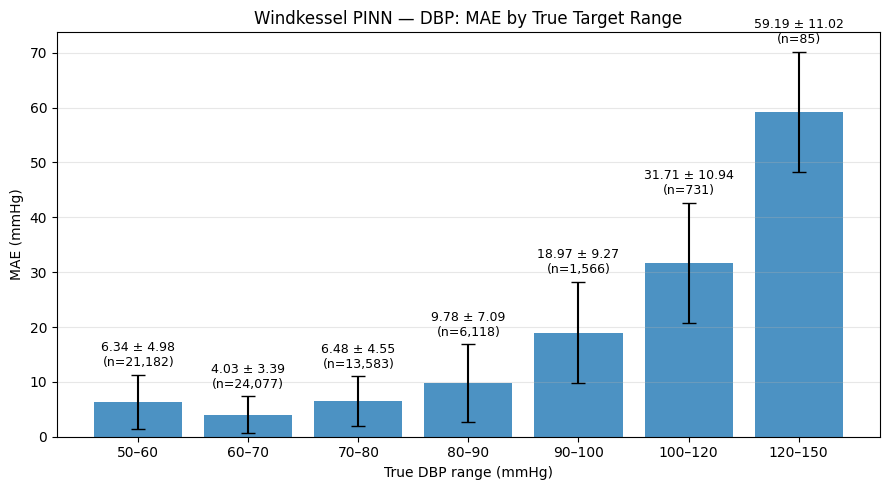

In [25]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.0001
)

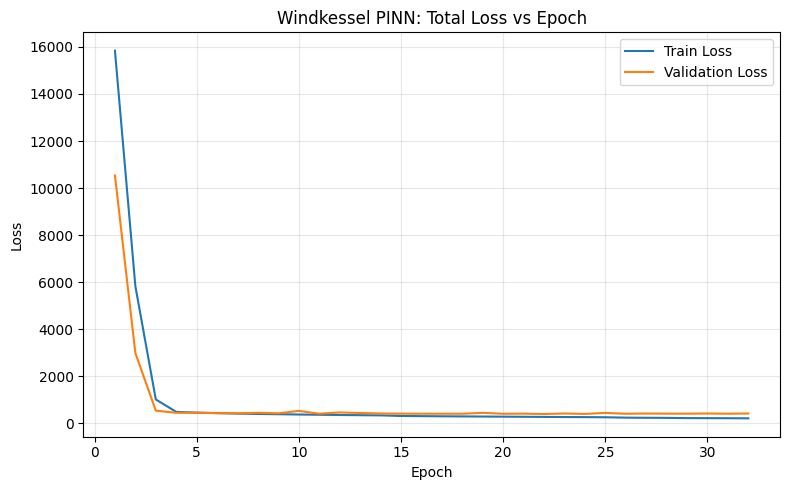

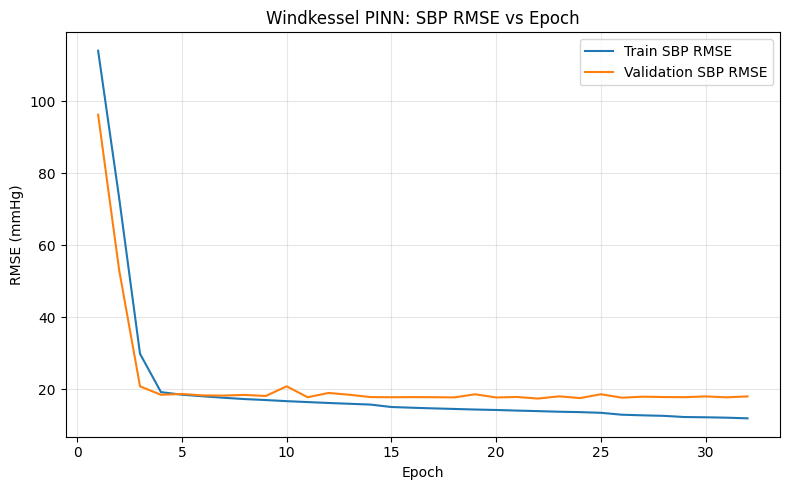

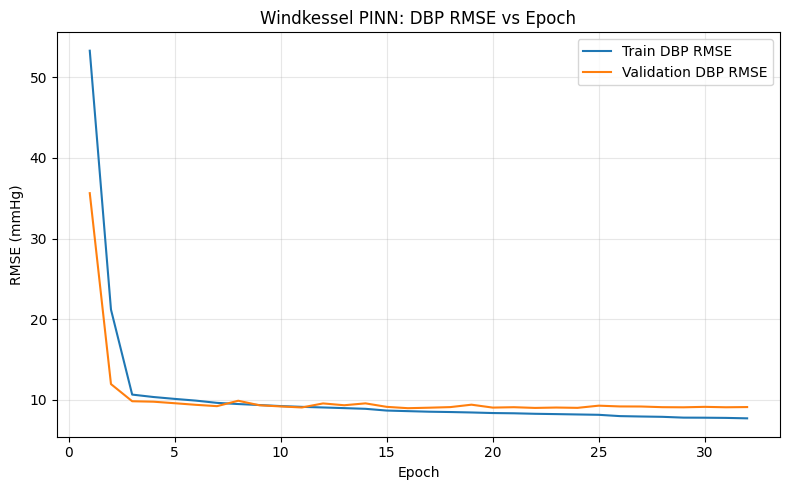

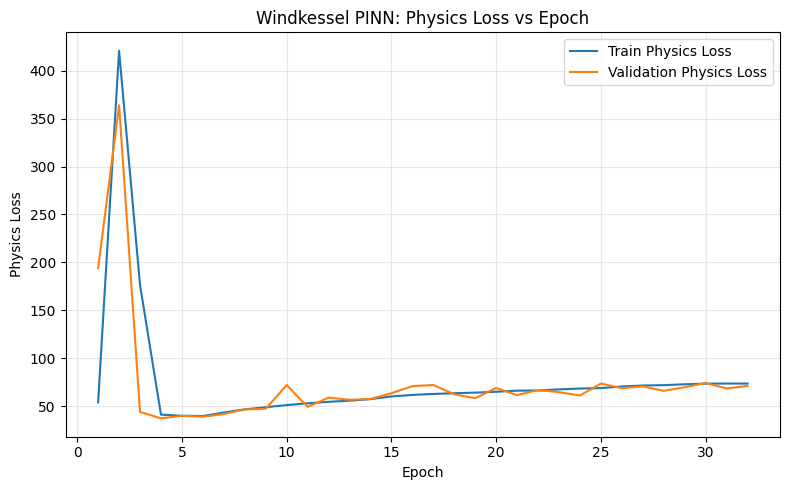

In [26]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16340.1241 | Train SBP MSE: 13352.7719 | Train DBP MSE: 2987.3098 | Train Phys: 42.4067 | Train RMSE: SBP=115.554, DBP=54.656 | Val Total: 11518.4560 | Val SBP MSE: 9957.0951 | Val DBP MSE: 1561.2129 | Val Phys: 147.9480 | Val RMSE: SBP=99.785, DBP=39.512 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6891.0240 | Train SBP MSE: 6248.2025 | Train DBP MSE: 642.4806 | Train Phys: 340.7897 | Train RMSE: SBP=79.046, DBP=25.347 | Val Total: 2834.6282 | Val SBP MSE: 2678.9072 | Val DBP MSE: 155.2527 | Val Phys: 468.3152 | Val RMSE: SBP=51.758, DBP=12.460 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1494.7317 | Train SBP MSE: 1369.6495 | Train DBP MSE: 124.8208 | Train Phys: 261.4542 | Train RMSE: SBP=37.009, DBP=11.172 | Val Total: 685.9234 | Val SBP MSE: 581.5418 | Val DBP MSE: 104.3282 | Val Phys: 53.4384 | Val RMSE: SBP=24.115, DBP=10.214 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 500.0040 | Train SBP MSE: 389.0922 | Train DBP MSE: 1

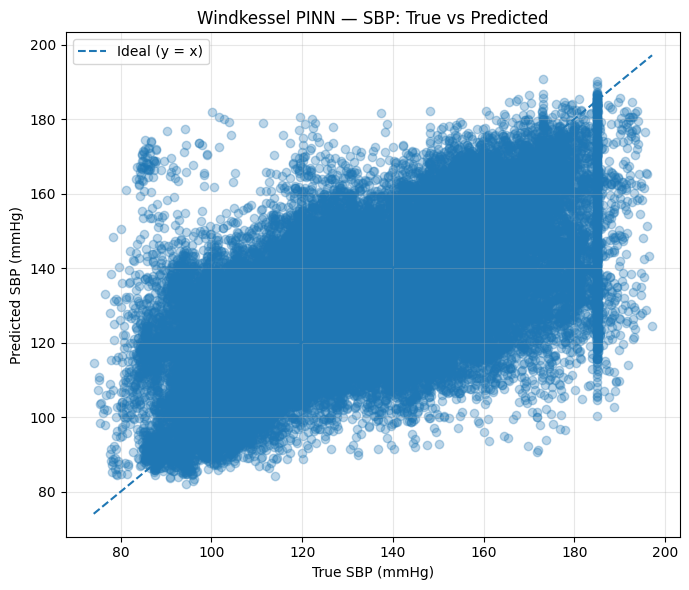

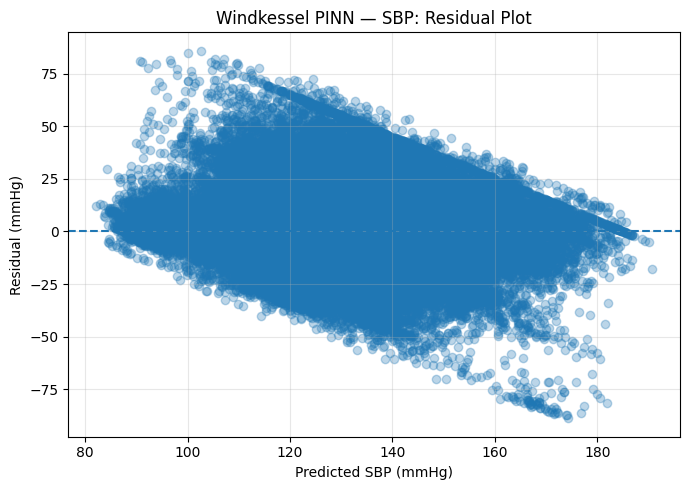

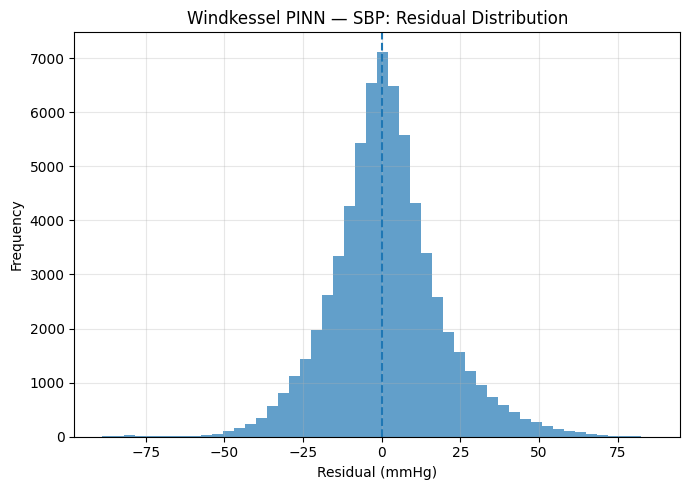

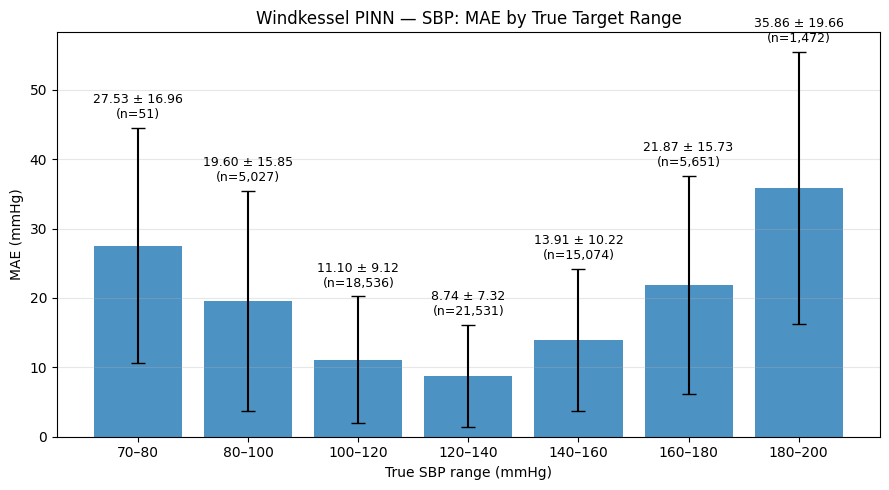


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.2176
MSE : 84.9639
R²  : 0.3148
MAE : 6.4915


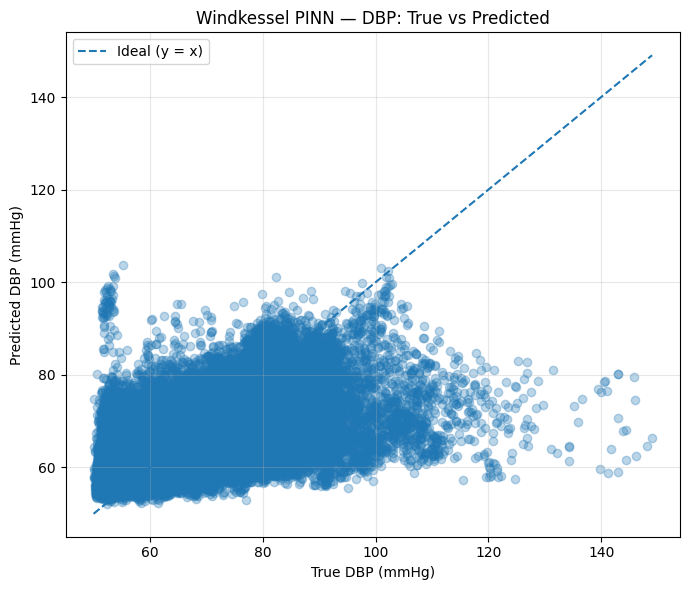

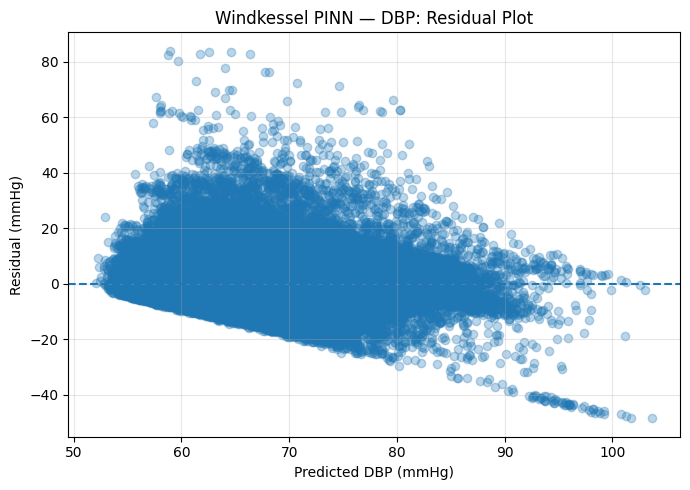

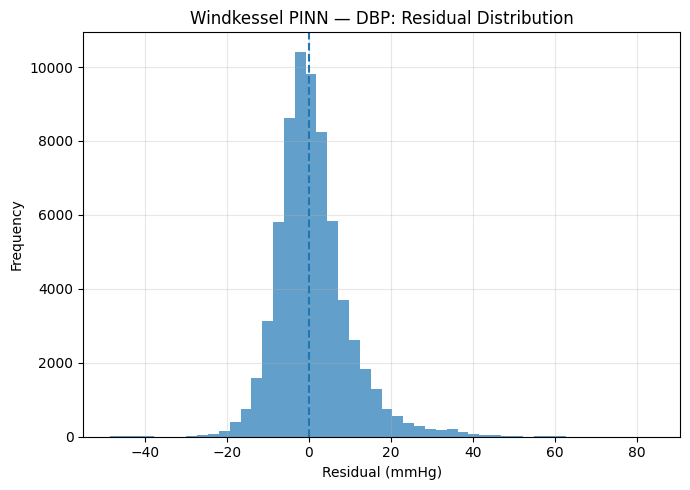

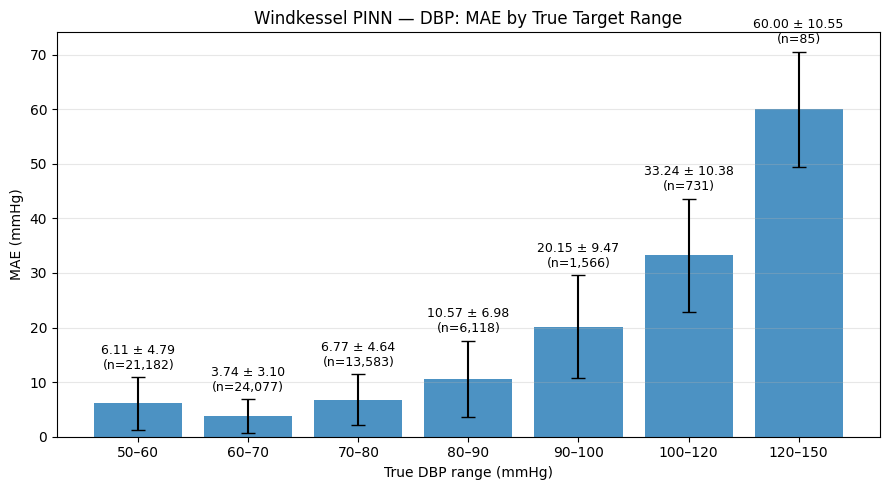

In [27]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.001
)

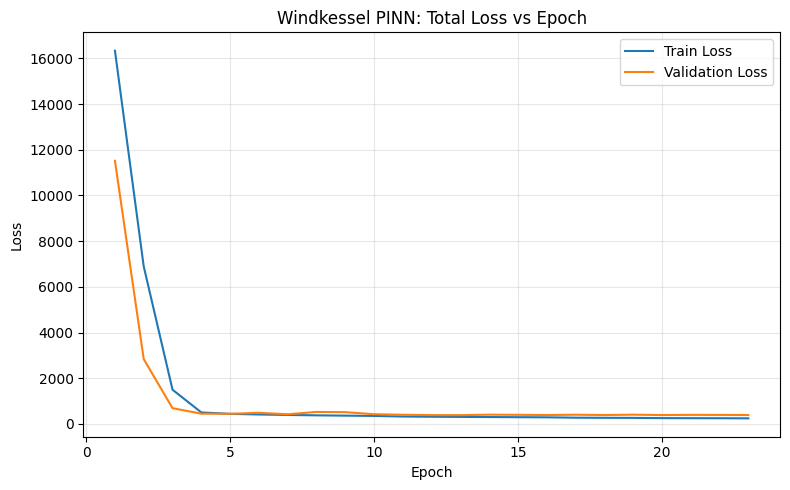

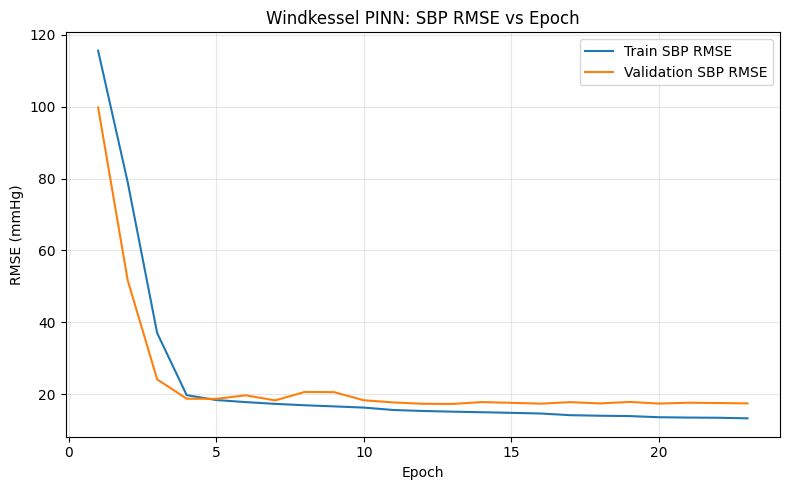

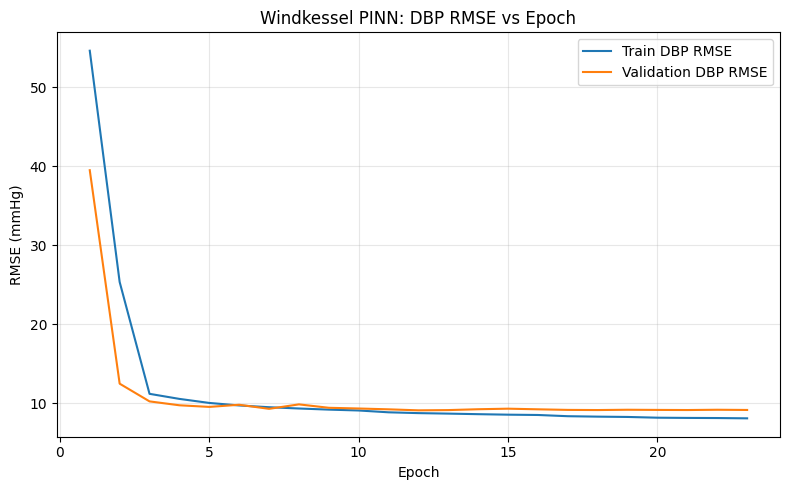

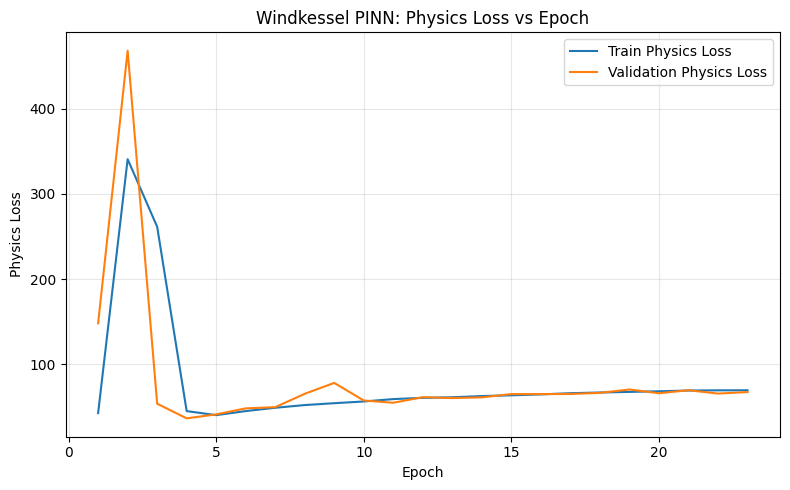

In [28]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16005.8505 | Train SBP MSE: 13063.8103 | Train DBP MSE: 2941.6181 | Train Phys: 42.2128 | Train RMSE: SBP=114.297, DBP=54.237 | Val Total: 11074.0062 | Val SBP MSE: 9597.8791 | Val DBP MSE: 1474.5447 | Val Phys: 158.2335 | Val RMSE: SBP=97.969, DBP=38.400 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6433.9904 | Train SBP MSE: 5848.2562 | Train DBP MSE: 582.3099 | Train Phys: 342.4233 | Train RMSE: SBP=76.474, DBP=24.131 | Val Total: 2433.3895 | Val SBP MSE: 2323.6035 | Val DBP MSE: 105.0729 | Val Phys: 471.3057 | Val RMSE: SBP=48.204, DBP=10.251 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1314.9632 | Train SBP MSE: 1188.3351 | Train DBP MSE: 124.4254 | Train Phys: 220.2738 | Train RMSE: SBP=34.472, DBP=11.155 | Val Total: 720.4379 | Val SBP MSE: 605.4521 | Val DBP MSE: 114.5318 | Val Phys: 45.4094 | Val RMSE: SBP=24.606, DBP=10.702 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 509.8600 | Train SBP MSE: 396.1440 | Train DBP MSE: 1

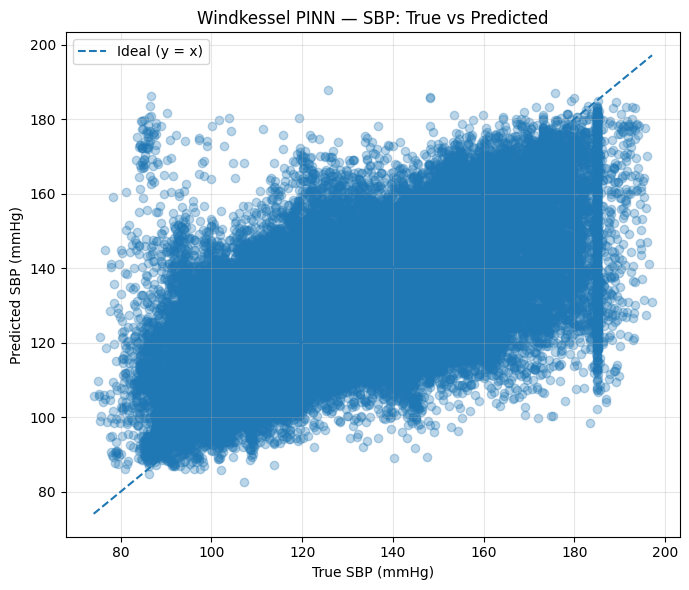

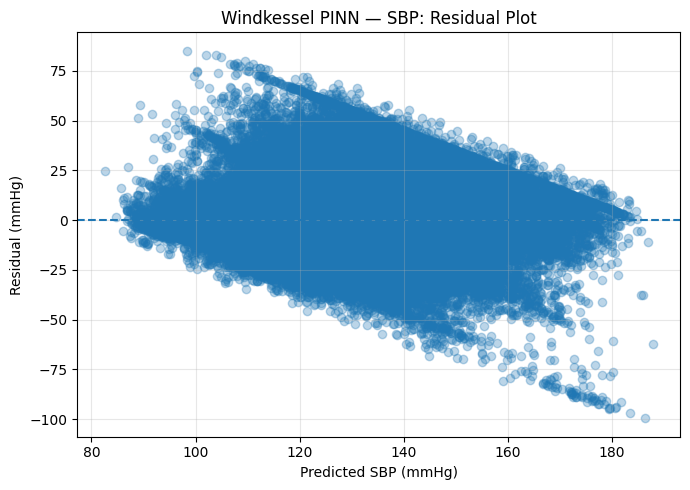

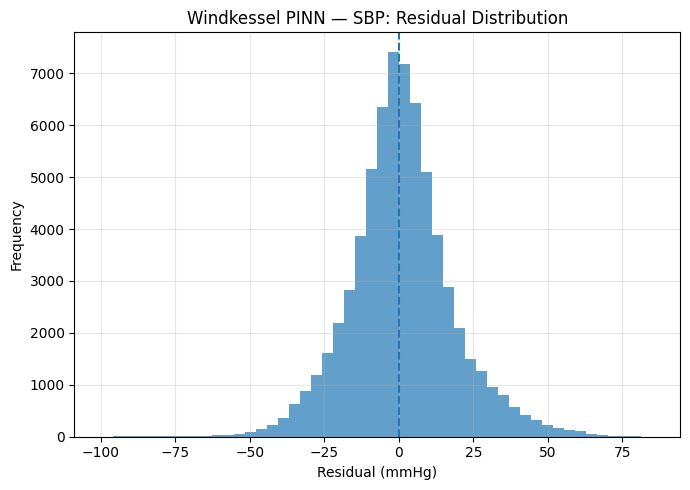

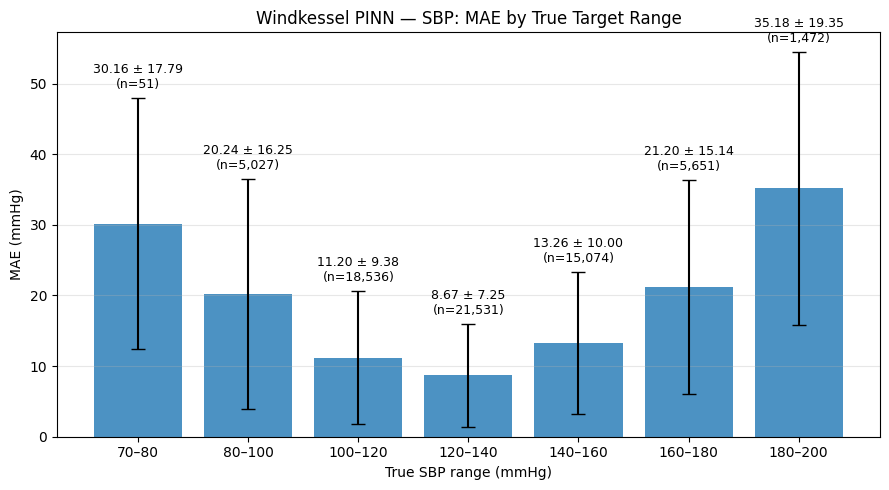


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.2483
MSE : 85.5317
R²  : 0.3102
MAE : 6.5335


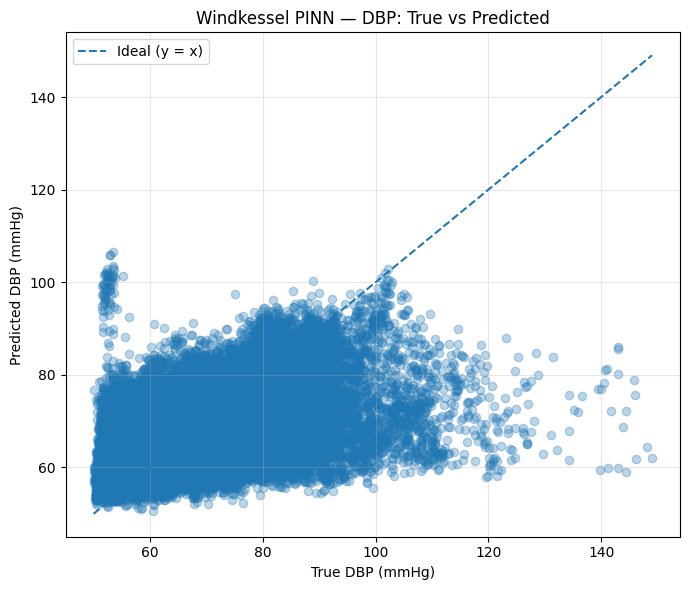

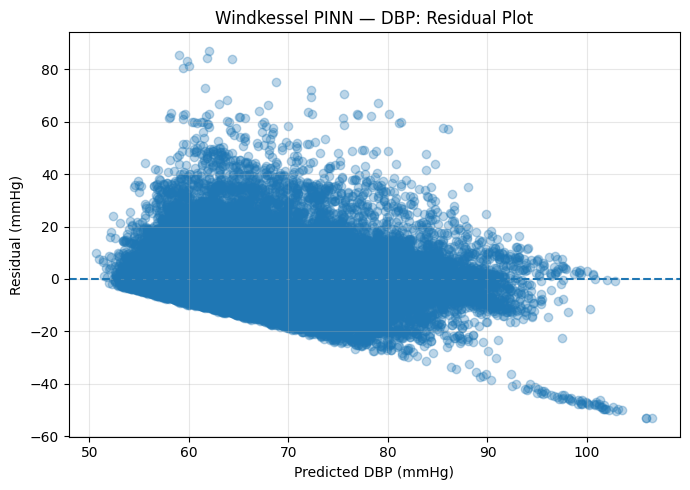

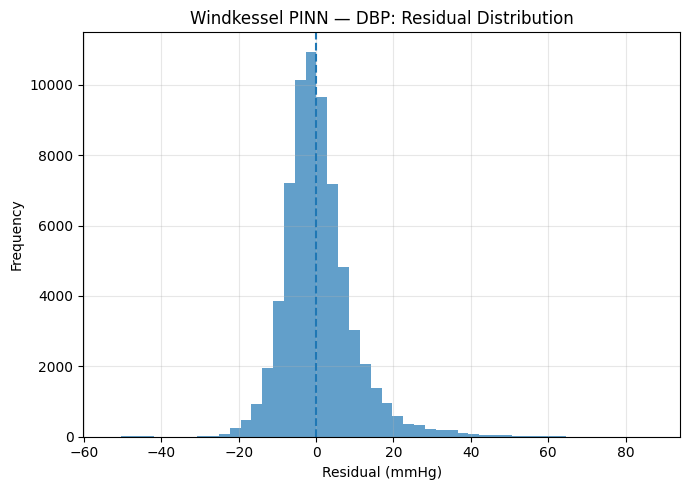

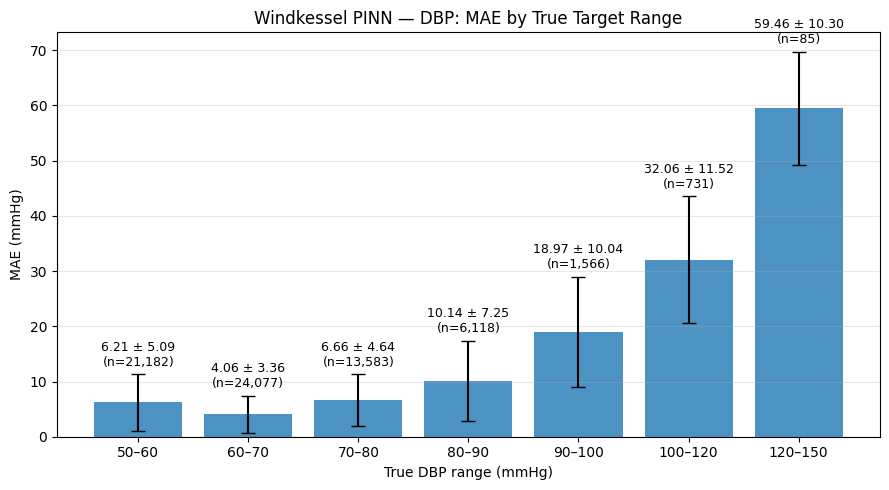

In [29]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.01
)

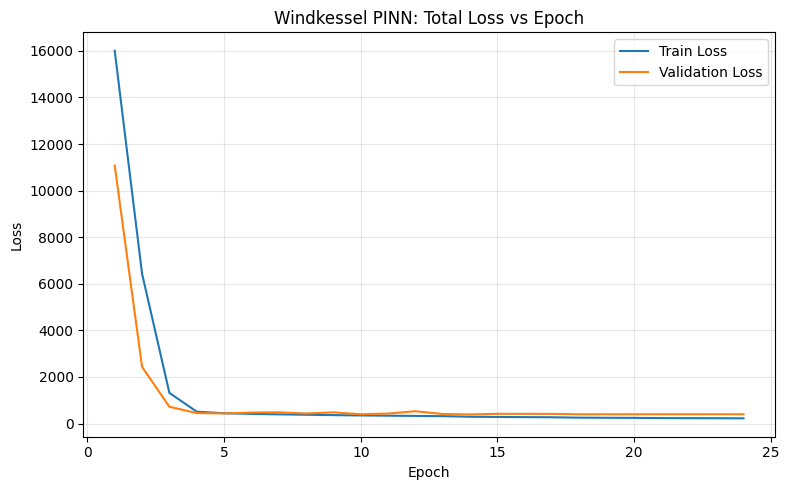

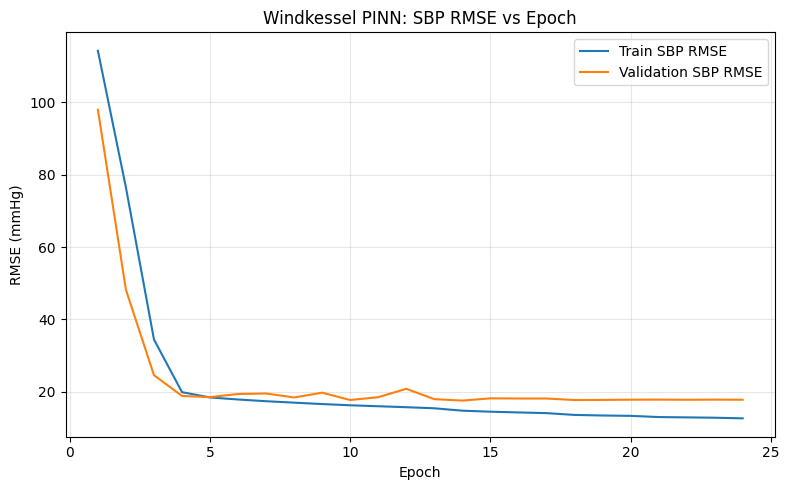

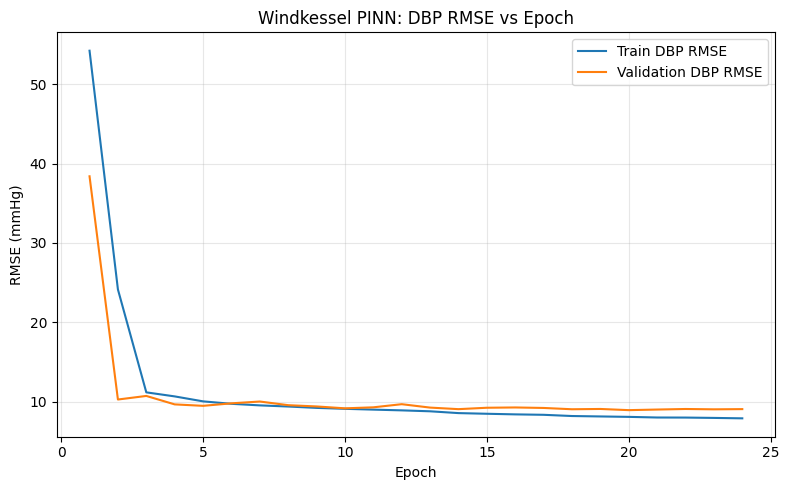

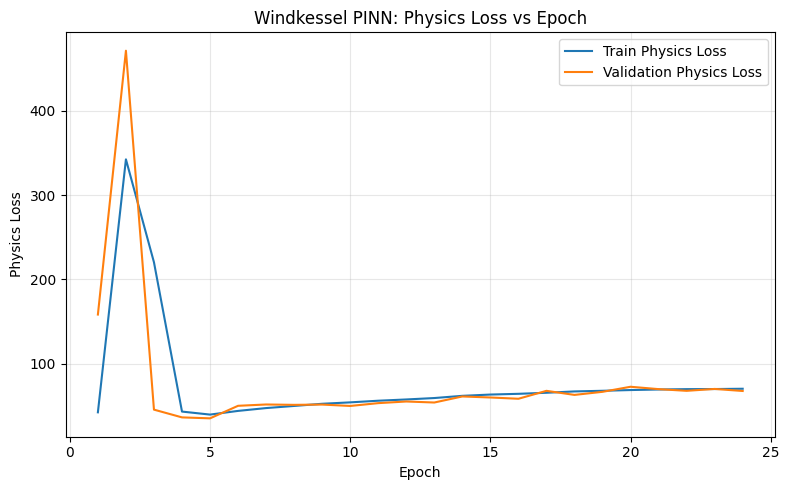

In [30]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15601.9190 | Train SBP MSE: 12760.2502 | Train DBP MSE: 2837.3152 | Train Phys: 43.5357 | Train RMSE: SBP=112.961, DBP=53.266 | Val Total: 11490.0150 | Val SBP MSE: 9883.4154 | Val DBP MSE: 1593.6873 | Val Phys: 129.1234 | Val RMSE: SBP=99.415, DBP=39.921 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6246.8909 | Train SBP MSE: 5652.5950 | Train DBP MSE: 561.9754 | Train Phys: 323.2055 | Train RMSE: SBP=75.184, DBP=23.706 | Val Total: 3020.4078 | Val SBP MSE: 2833.4089 | Val DBP MSE: 151.3961 | Val Phys: 356.0278 | Val RMSE: SBP=53.230, DBP=12.304 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1269.3524 | Train SBP MSE: 1132.2523 | Train DBP MSE: 118.7953 | Train Phys: 183.0475 | Train RMSE: SBP=33.649, DBP=10.899 | Val Total: 540.0248 | Val SBP MSE: 439.1162 | Val DBP MSE: 96.1853 | Val Phys: 47.2334 | Val RMSE: SBP=20.955, DBP=9.807 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 495.4759 | Train SBP MSE: 382.7887 | Train DBP MSE: 108

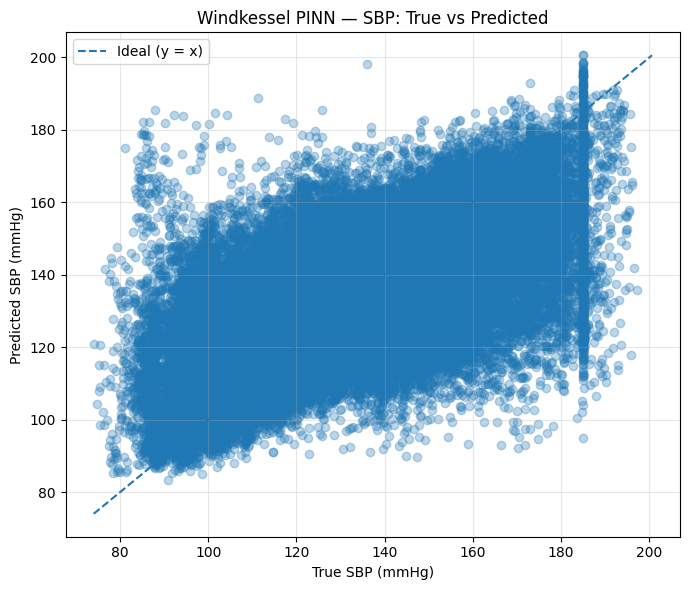

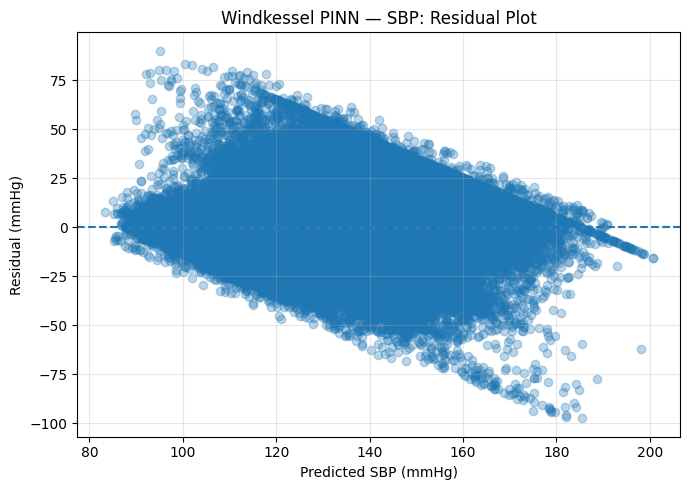

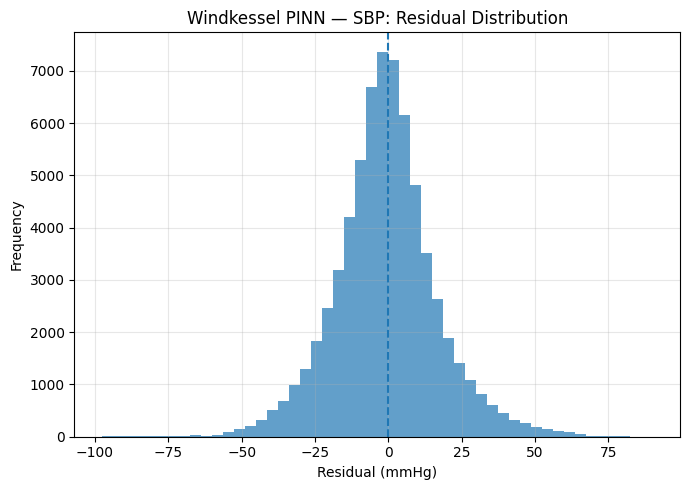

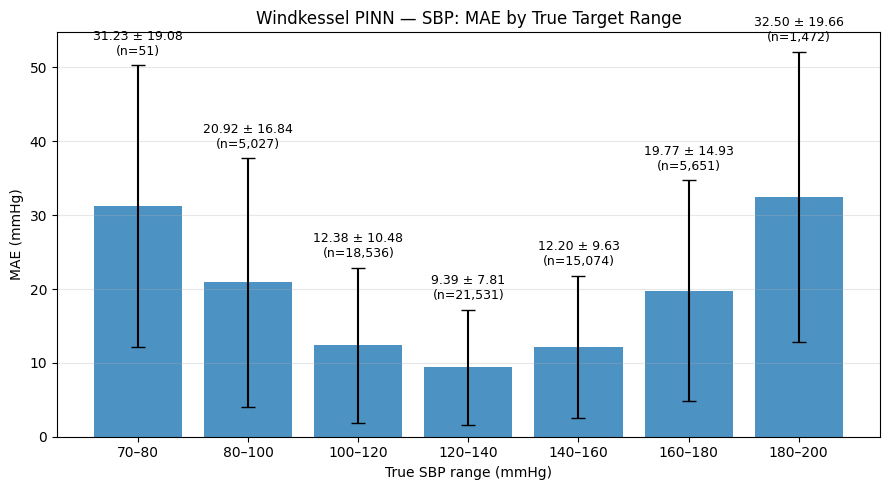


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.2479
MSE : 85.5235
R²  : 0.3103
MAE : 6.7580


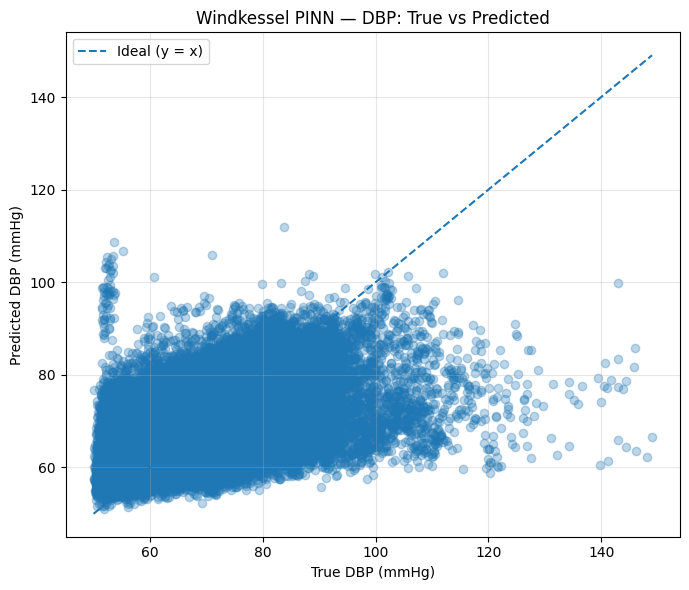

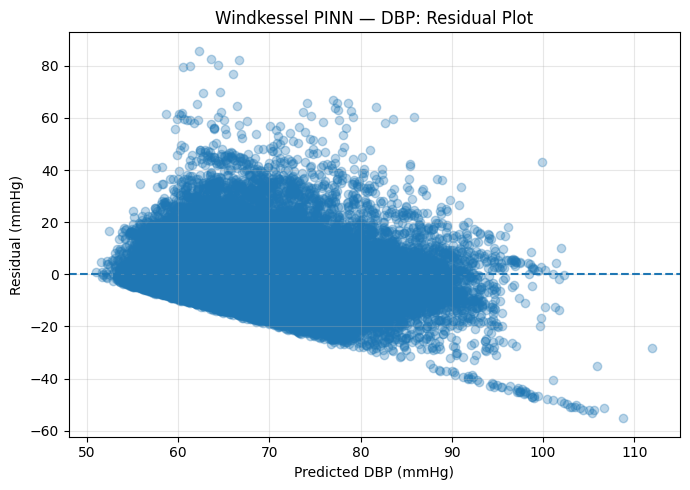

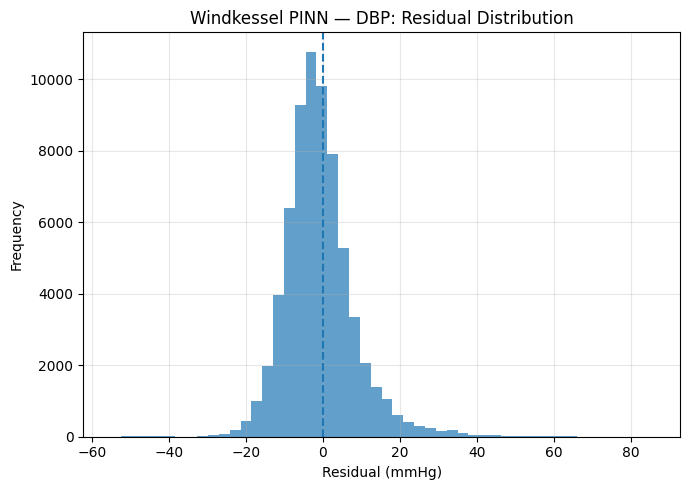

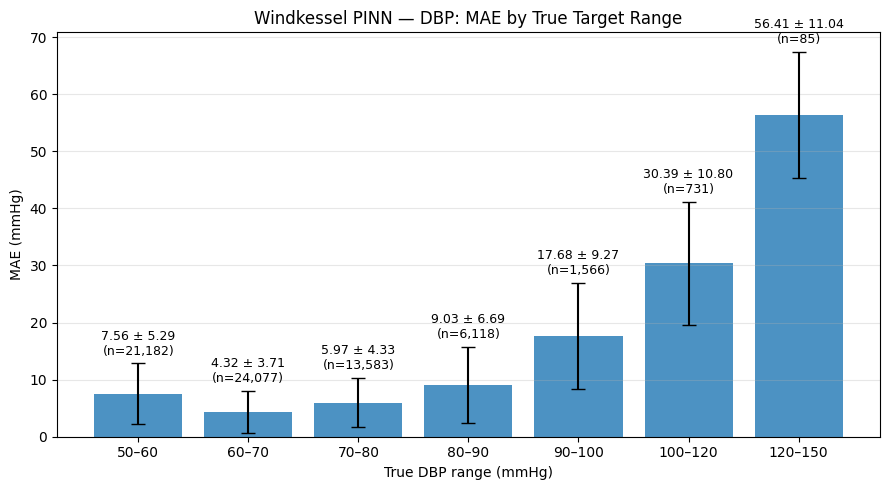

In [31]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.1
)

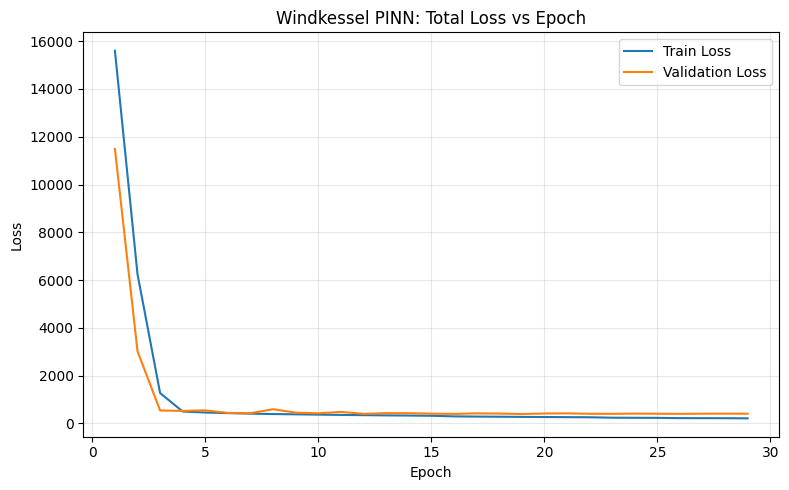

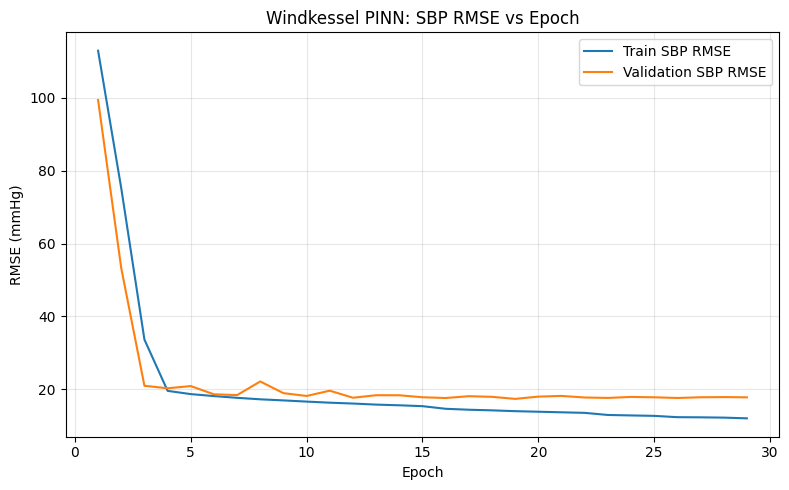

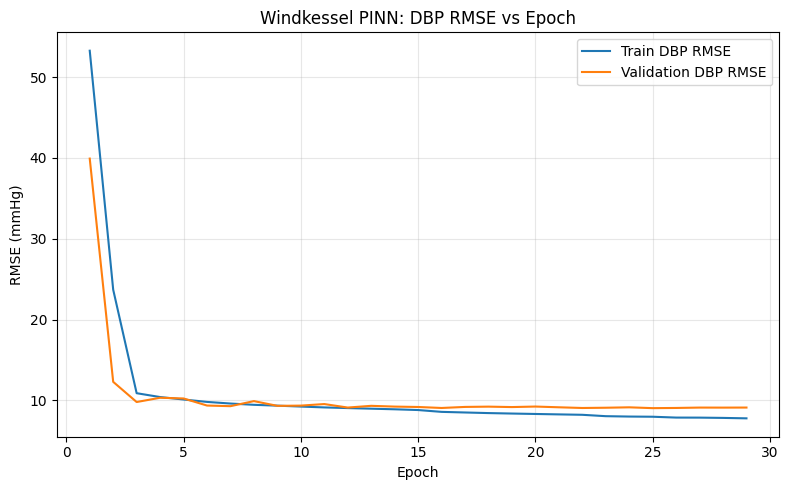

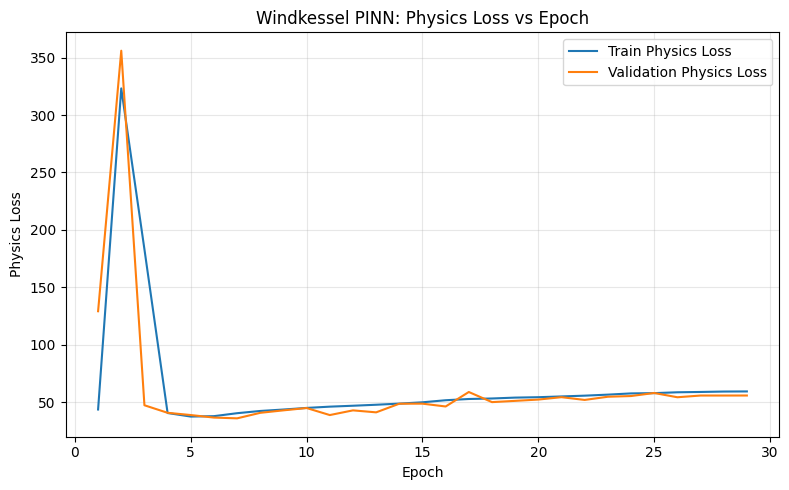

In [32]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15601.9236 | Train SBP MSE: 12697.1803 | Train DBP MSE: 2869.7592 | Train Phys: 34.9841 | Train RMSE: SBP=112.682, DBP=53.570 | Val Total: 10846.2598 | Val SBP MSE: 9209.4627 | Val DBP MSE: 1533.5289 | Val Phys: 103.2682 | Val RMSE: SBP=95.966, DBP=39.160 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6669.9178 | Train SBP MSE: 5730.6267 | Train DBP MSE: 785.7002 | Train Phys: 153.5909 | Train RMSE: SBP=75.701, DBP=28.030 | Val Total: 2997.5803 | Val SBP MSE: 2588.8587 | Val DBP MSE: 273.8403 | Val Phys: 134.8814 | Val RMSE: SBP=50.881, DBP=16.548 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1594.4542 | Train SBP MSE: 1323.3663 | Train DBP MSE: 196.3704 | Train Phys: 74.7176 | Train RMSE: SBP=36.378, DBP=14.013 | Val Total: 1021.2866 | Val SBP MSE: 813.9065 | Val DBP MSE: 176.0027 | Val Phys: 31.3775 | Val RMSE: SBP=28.529, DBP=13.267 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 558.9035 | Train SBP MSE: 410.8604 | Train DBP MSE: 1

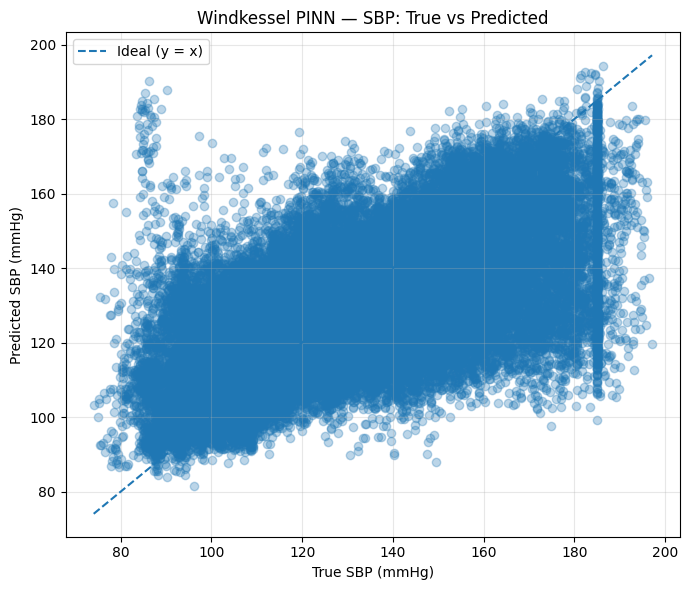

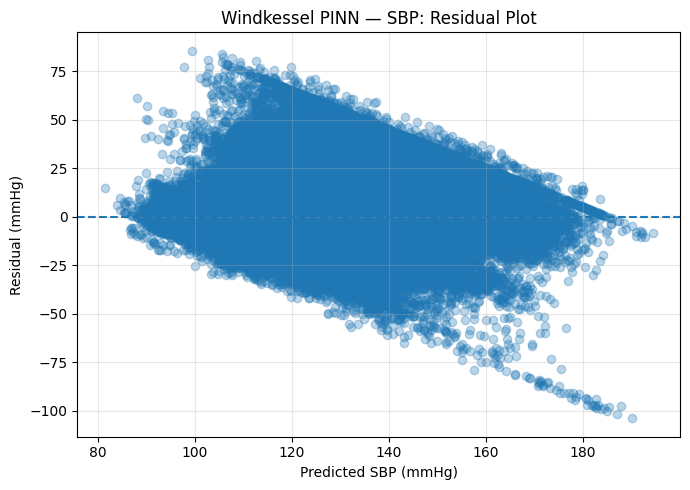

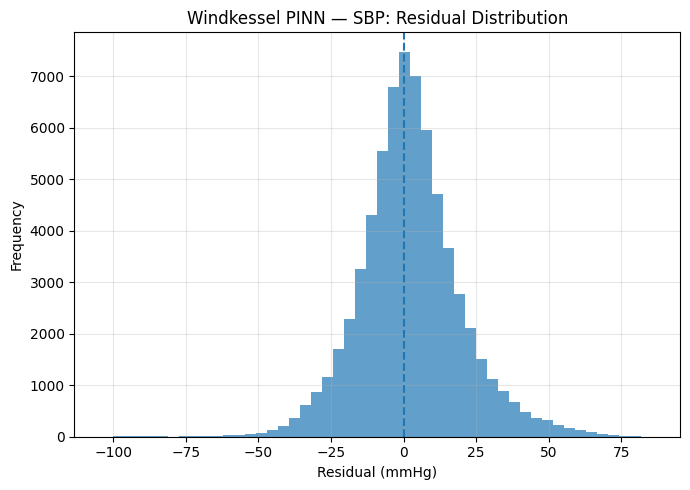

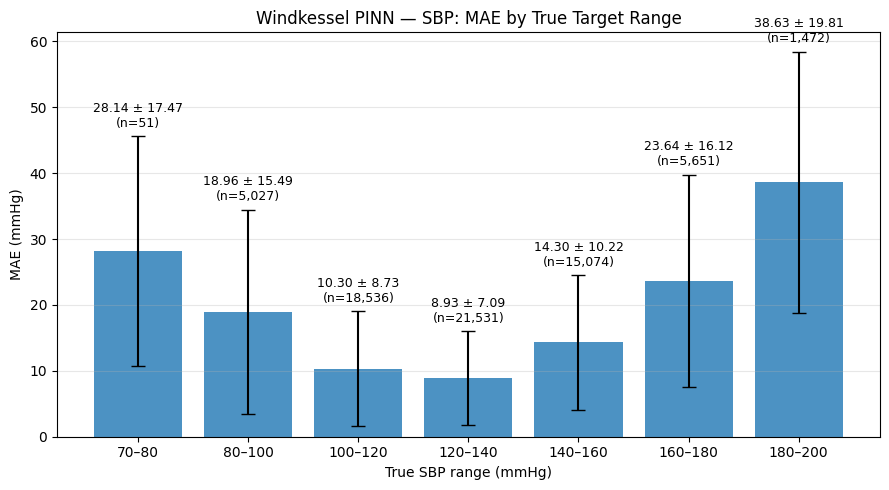


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.5947
MSE : 92.0574
R²  : 0.2576
MAE : 6.9257


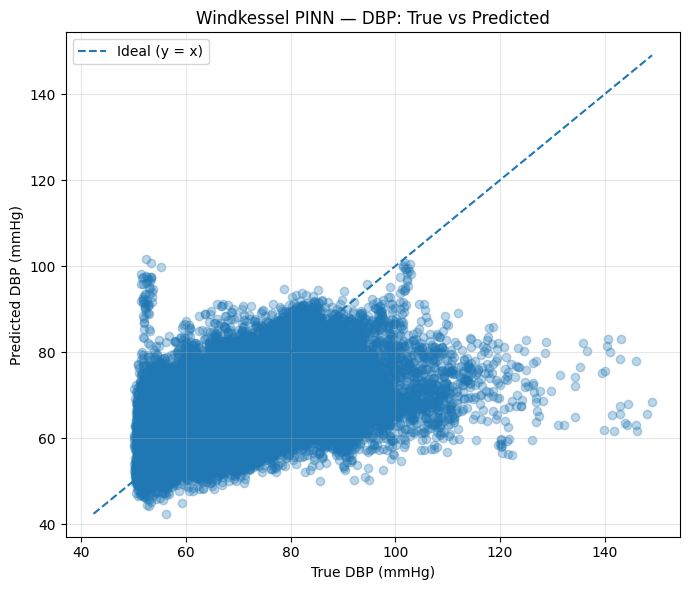

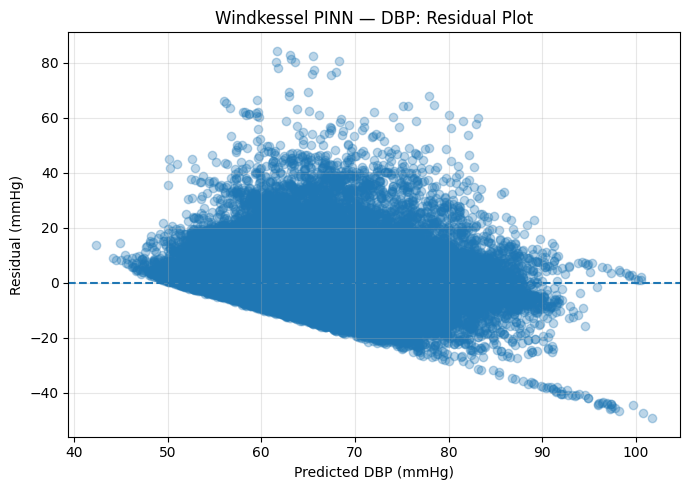

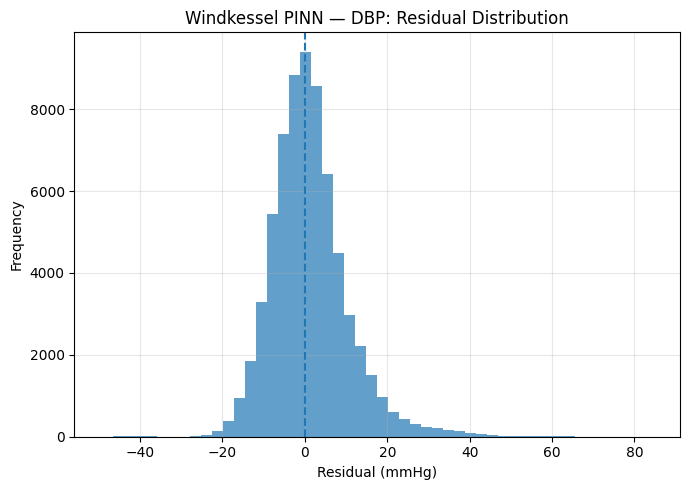

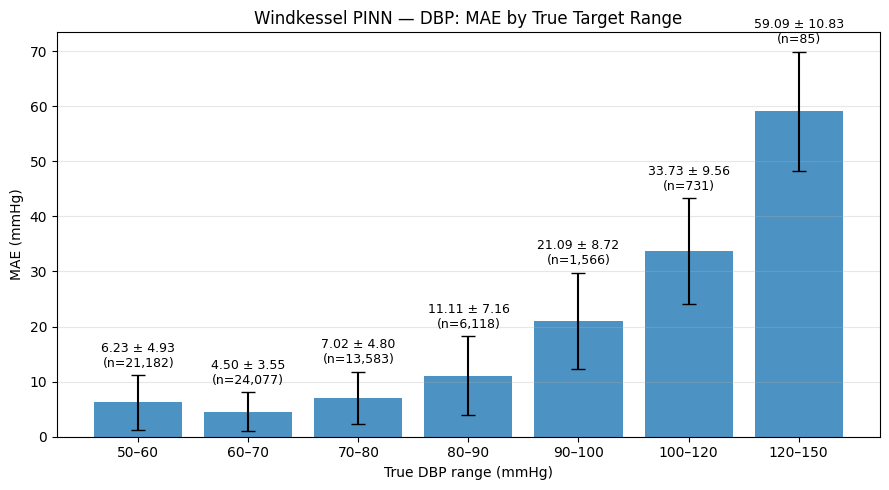

In [33]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=1
)

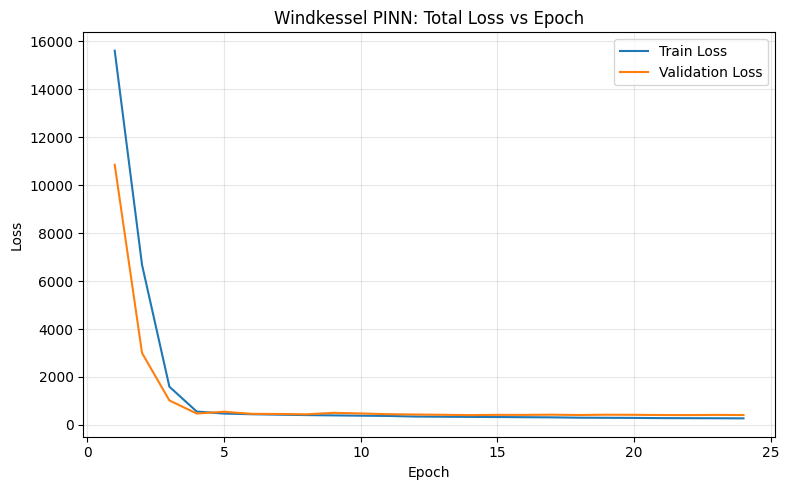

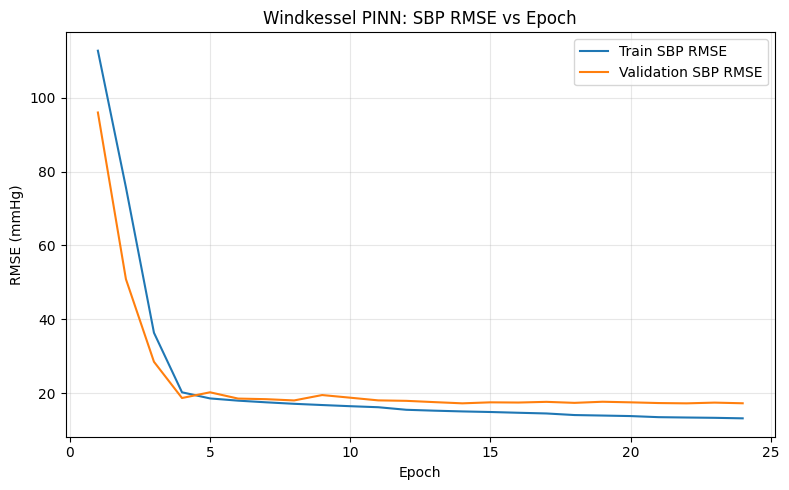

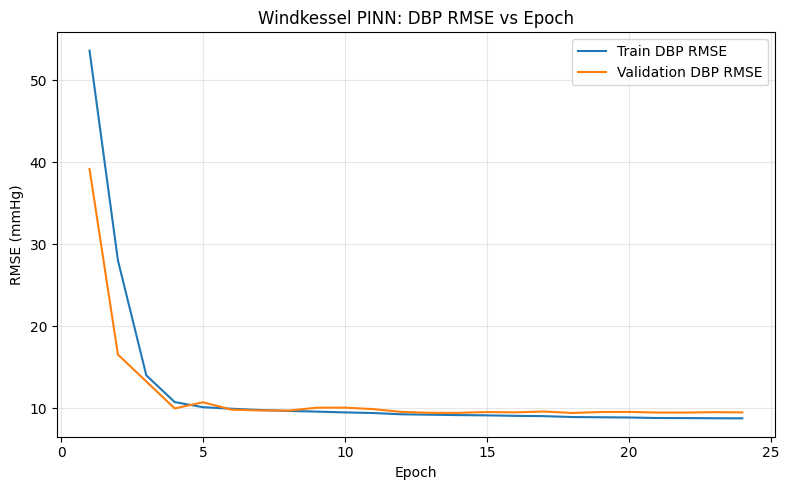

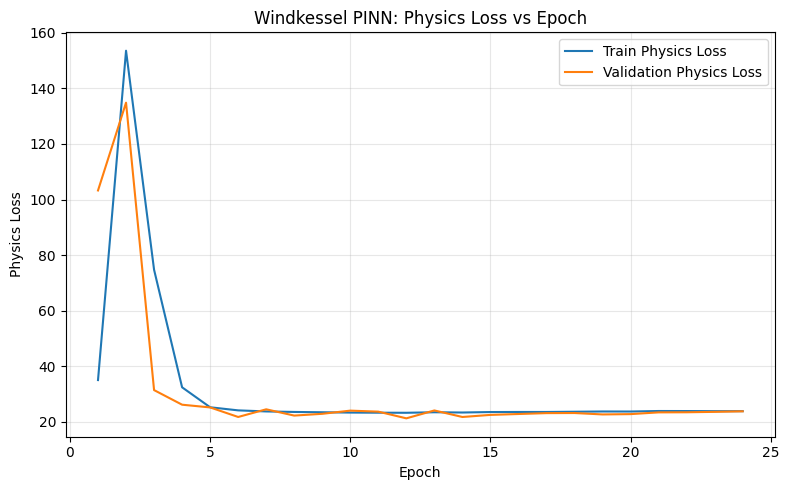

In [34]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16178.9462 | Train SBP MSE: 12973.4018 | Train DBP MSE: 3109.4068 | Train Phys: 9.6138 | Train RMSE: SBP=113.901, DBP=55.762 | Val Total: 11549.1198 | Val SBP MSE: 9302.1308 | Val DBP MSE: 2100.4421 | Val Phys: 14.6547 | Val RMSE: SBP=96.448, DBP=45.831 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 7579.5987 | Train SBP MSE: 6033.9531 | Train DBP MSE: 1382.4962 | Train Phys: 16.3149 | Train RMSE: SBP=77.679, DBP=37.182 | Val Total: 4461.4396 | Val SBP MSE: 3521.6026 | Val DBP MSE: 748.0499 | Val Phys: 19.1787 | Val RMSE: SBP=59.343, DBP=27.351 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1840.9325 | Train SBP MSE: 1356.6801 | Train DBP MSE: 333.1675 | Train Phys: 15.1085 | Train RMSE: SBP=36.833, DBP=18.253 | Val Total: 713.4643 | Val SBP MSE: 451.3962 | Val DBP MSE: 124.4910 | Val Phys: 13.7577 | Val RMSE: SBP=21.246, DBP=11.158 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 678.9816 | Train SBP MSE: 403.0360 | Train DBP MSE: 122.1

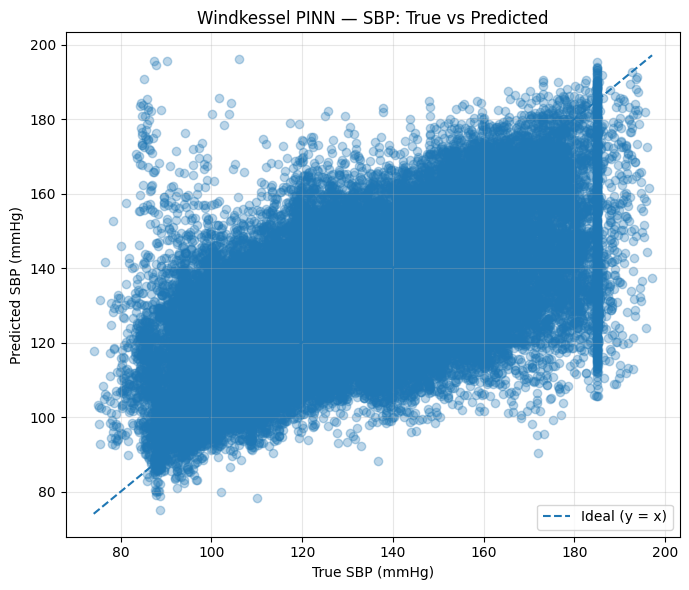

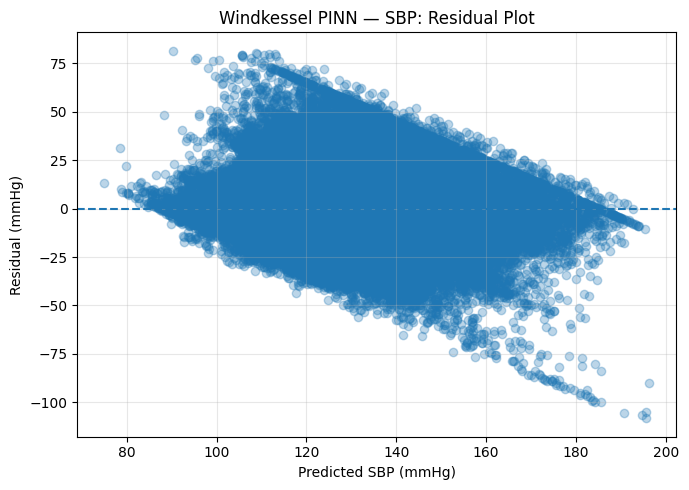

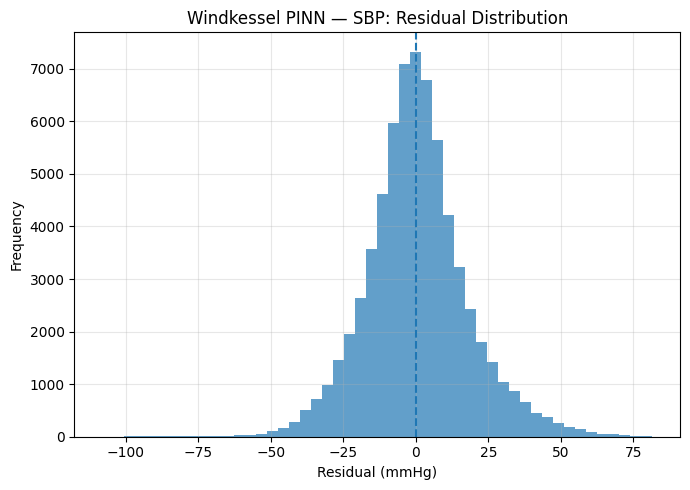

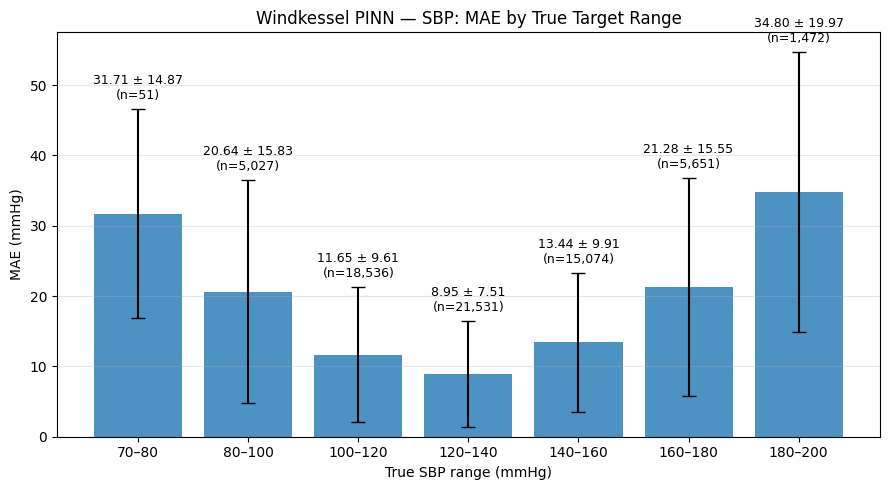


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 10.4647
MSE : 109.5093
R²  : 0.1168
MAE : 7.7825


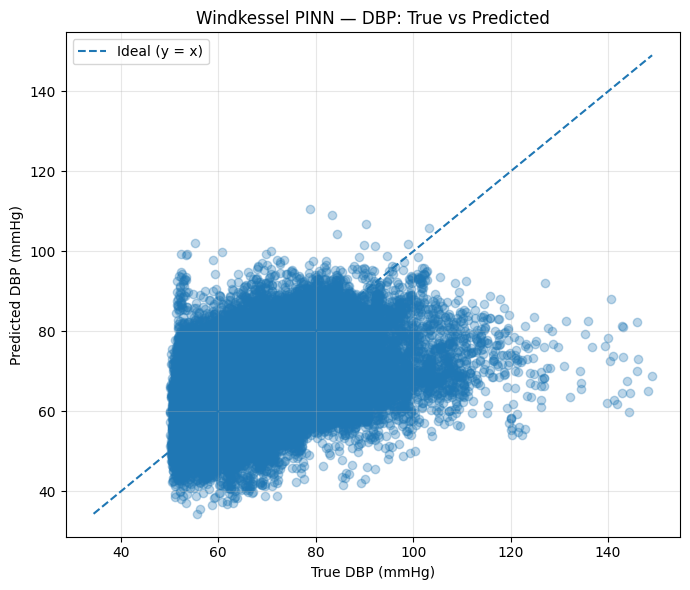

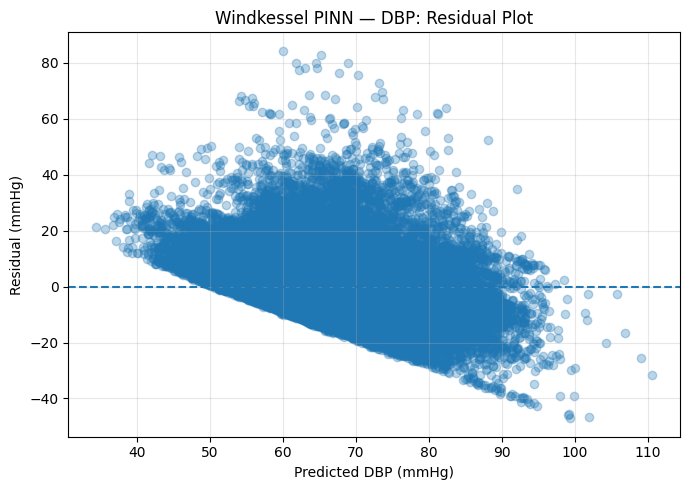

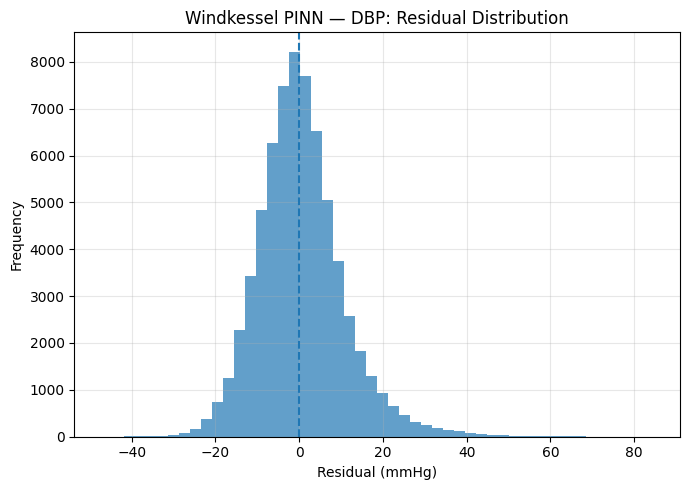

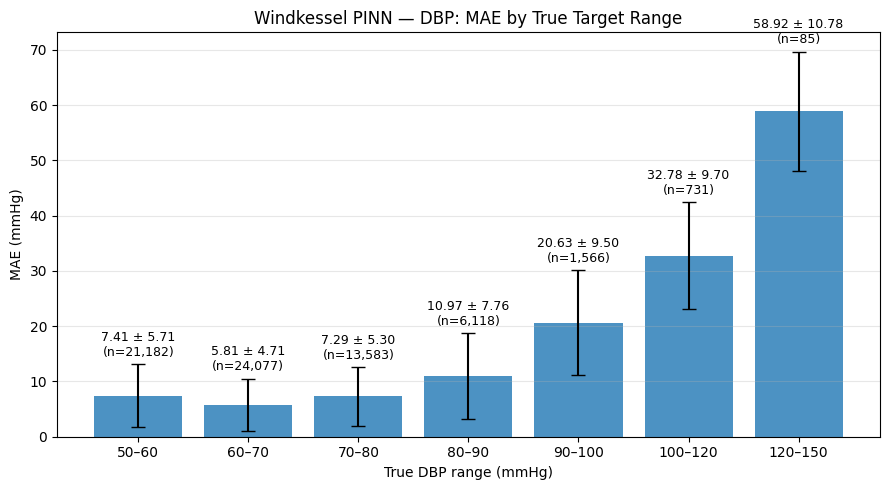

In [35]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=10
)

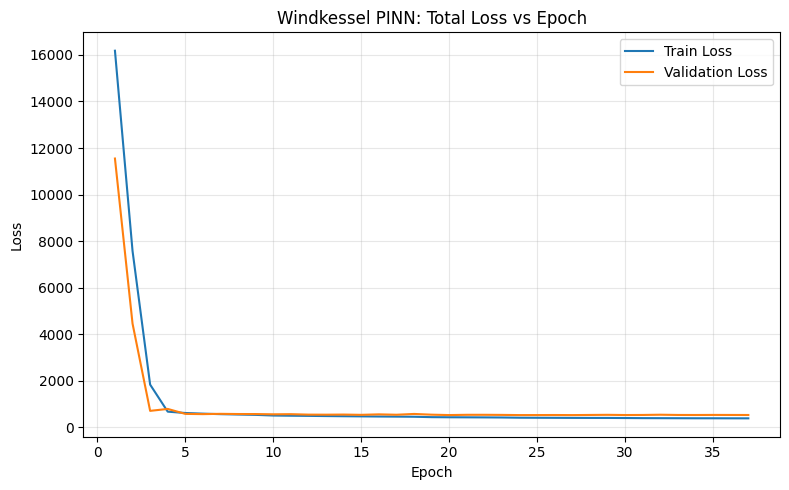

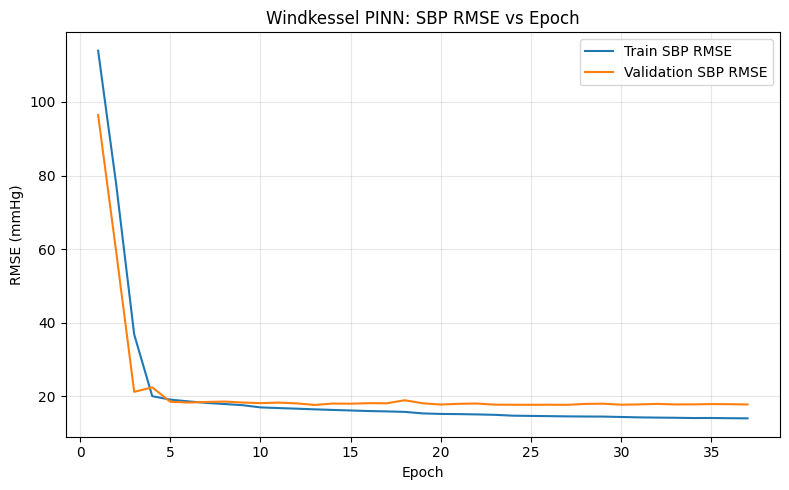

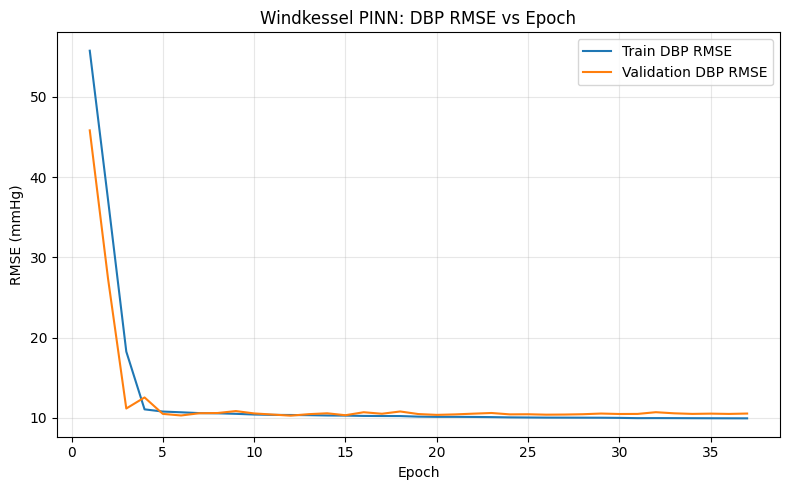

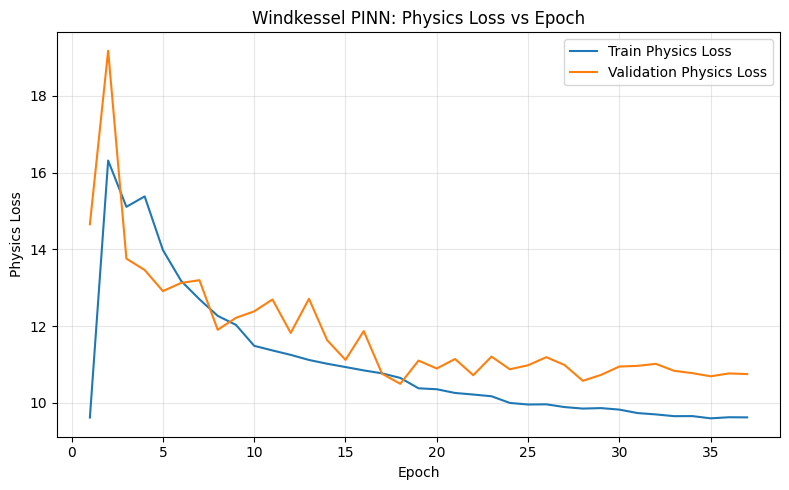

In [36]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16629.9672 | Train SBP MSE: 13119.9462 | Train DBP MSE: 3401.4203 | Train Phys: 1.0860 | Train RMSE: SBP=114.542, DBP=58.322 | Val Total: 12254.4223 | Val SBP MSE: 9562.4531 | Val DBP MSE: 2358.1979 | Val Phys: 3.3377 | Val RMSE: SBP=97.788, DBP=48.561 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 8024.4565 | Train SBP MSE: 6079.9511 | Train DBP MSE: 1585.9763 | Train Phys: 3.5853 | Train RMSE: SBP=77.974, DBP=39.824 | Val Total: 4409.4616 | Val SBP MSE: 3070.2577 | Val DBP MSE: 809.3608 | Val Phys: 5.2984 | Val RMSE: SBP=55.410, DBP=28.449 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 2972.0385 | Train SBP MSE: 1780.5384 | Train DBP MSE: 485.9285 | Train Phys: 7.0557 | Train RMSE: SBP=42.196, DBP=22.044 | Val Total: 1689.7505 | Val SBP MSE: 608.5962 | Val DBP MSE: 163.0428 | Val Phys: 9.1811 | Val RMSE: SBP=24.670, DBP=12.769 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 1776.3583 | Train SBP MSE: 694.3983 | Train DBP MSE: 207.4935

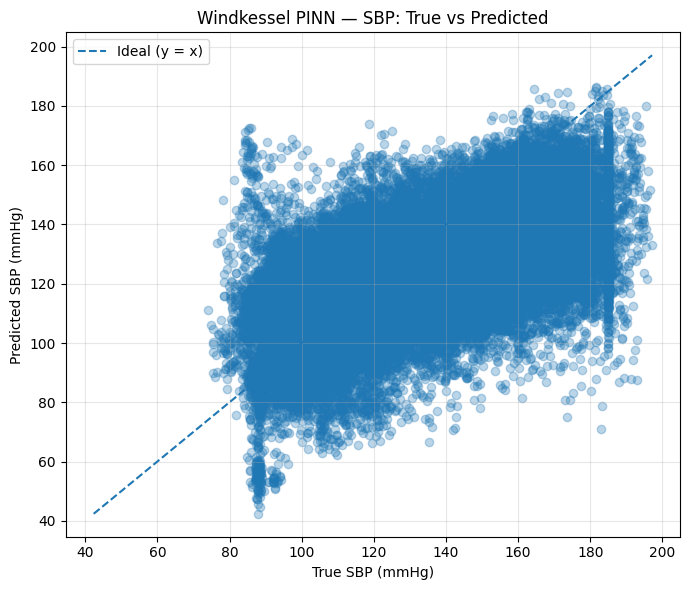

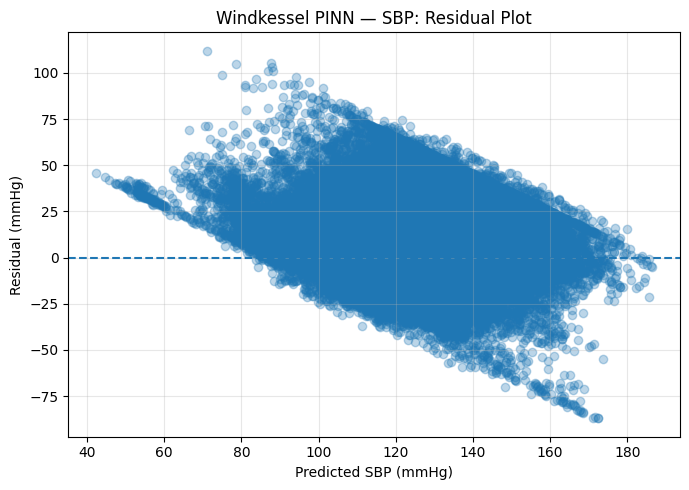

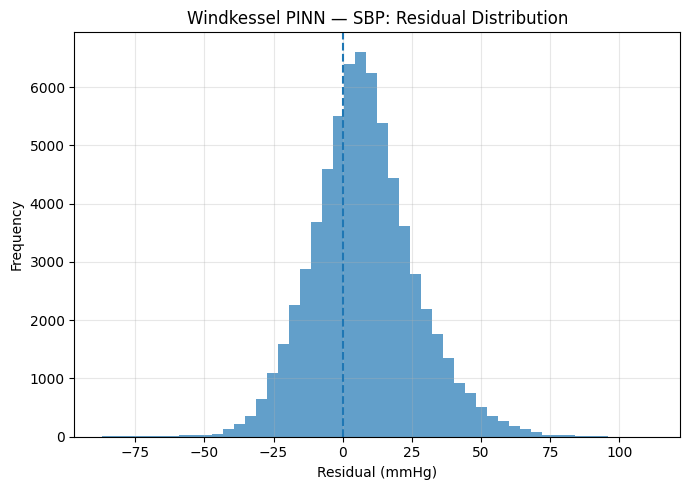

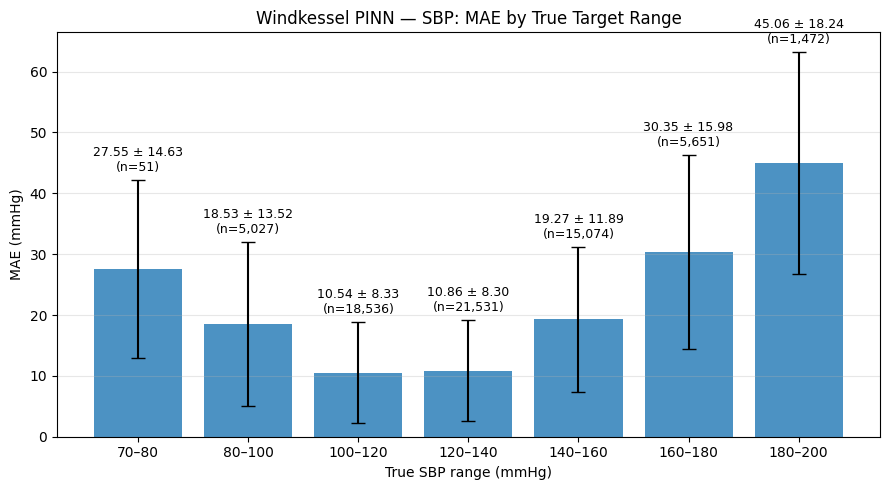


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 11.9902
MSE : 143.7644
R²  : -0.1594
MAE : 8.8154


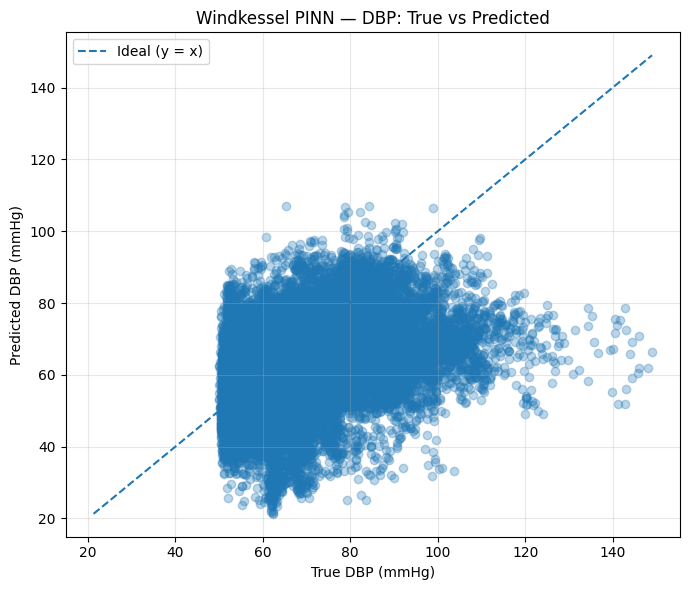

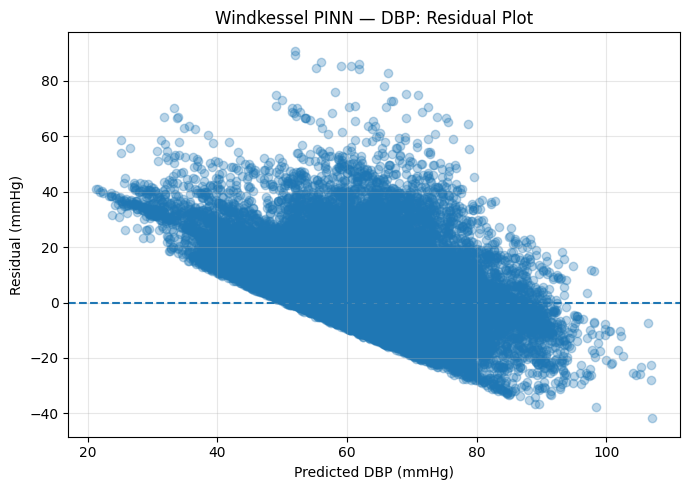

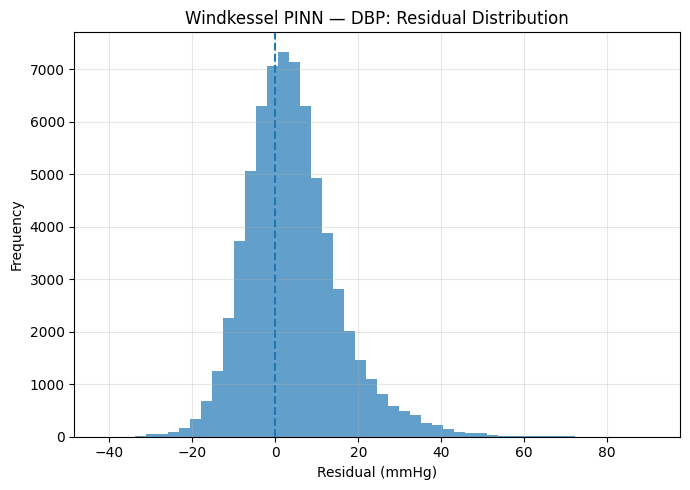

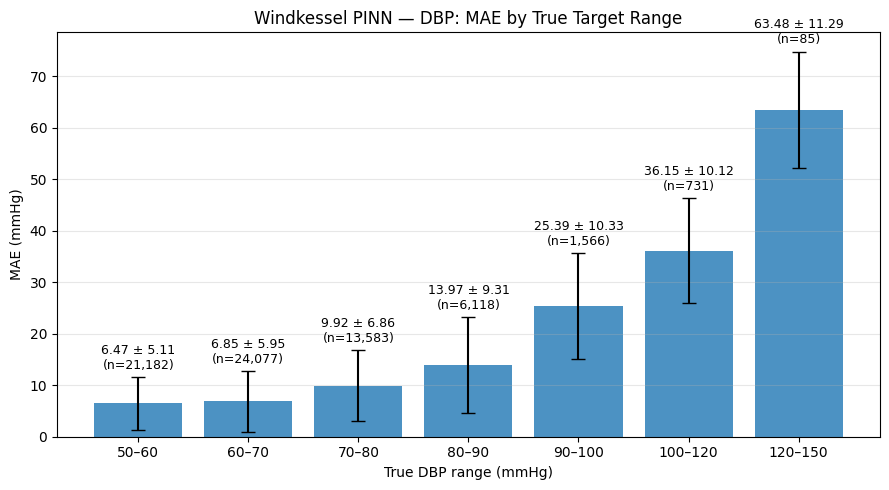

In [37]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=100
)

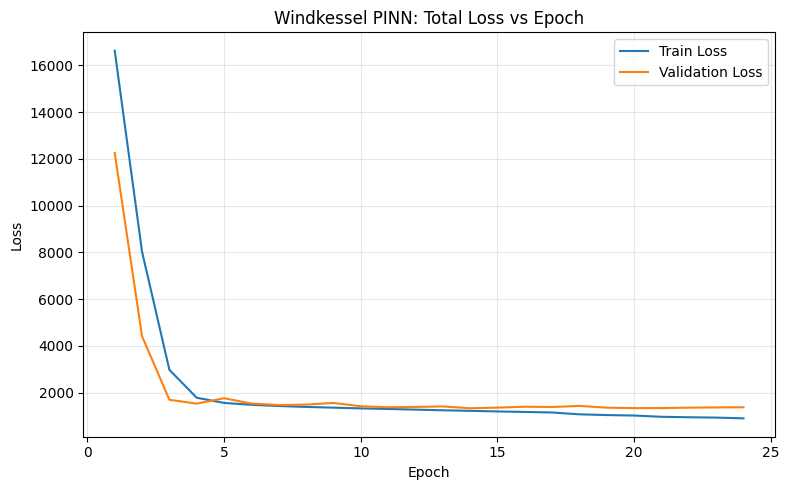

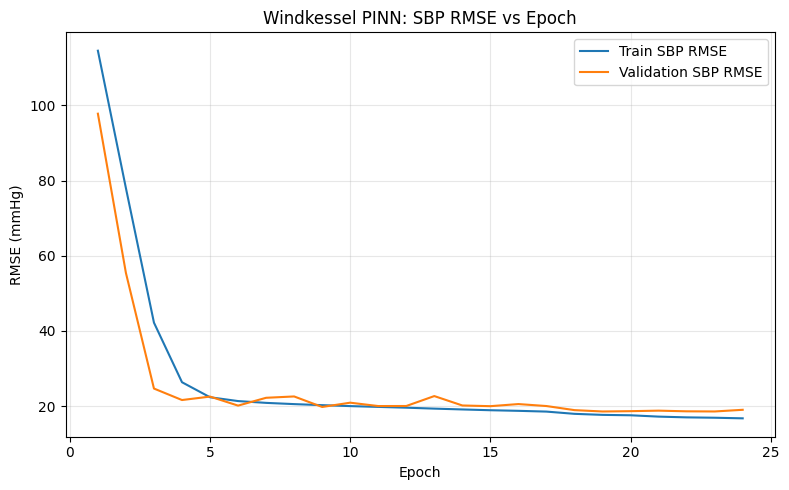

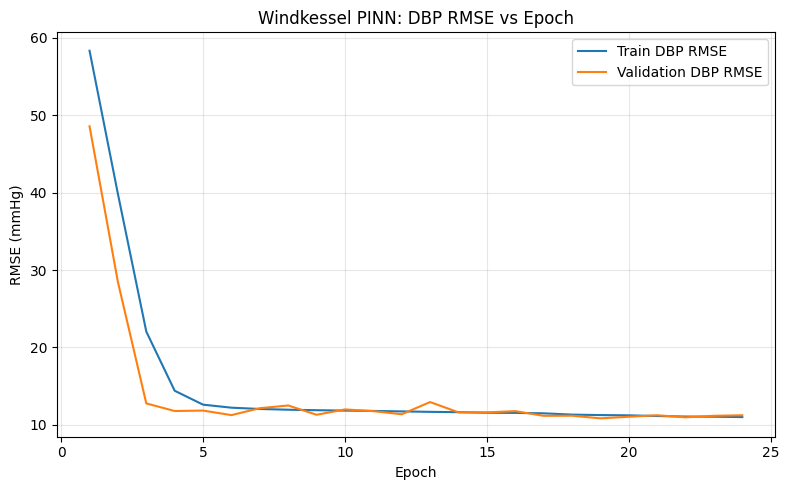

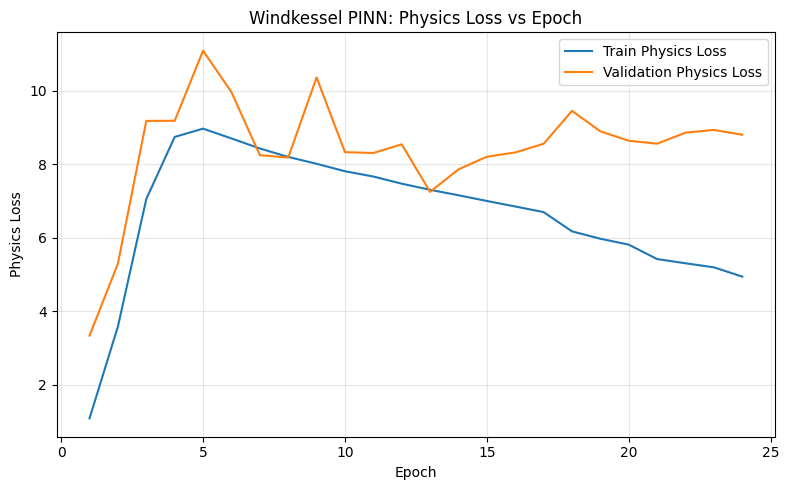

In [38]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)